# NVIDIA Stock Analysis

### INTRODUCTION

**Goal:** Analyse NVIDIA daily stock price data (2010–today) by discovering market regimes with unsupervised clustering and then use those regime labels as state features in a simple RL trading environment. 

**Data Source:** This NVIDIA daily stock price dataset was obtained using the yfinance Python library, with each entry representing a single trading day.

**Metric:** 
* **Primary Metric:** Cumulative Profit and Loss (PnL) vs. Buy-and-Hold baseline
* **Secondary Metrics:** Average Daily Return, Maximum Drawdown, Hit Ratio (accuracy of profitable actions), and Turnover

**Features:**
- **Date:** The date of the stock price record.
- **Open:** The stock price at the beginning of the trading day.
- **High:** The highest price Nvidia stock reached during the day.
- **Low:** The lowest price Nvidia stock reached during the day.
- **Close:** The stock price at the end of the trading day.
- **Volume:** The total number of Nvidia shares traded during the day.

**Notebook Structure:**
1. Data Overview
2. Data Preparation  
3. Exploratory Data Analysis
4. Unsupervised Learning 
5. Reinforcement Learning 
6. Conclusion & Improvements

### 1. DATA OVERVIEW

**1.1 Loading Libraries & Dataset**

In [381]:
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_digits
from sklearn.decomposition import NMF
from sklearn.datasets import fetch_20newsgroups_vectorized
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.datasets import make_moons
import pandas as pd
import warnings
import seaborn as sns
warnings.filterwarnings('ignore', category=FutureWarning)
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE



df = pd.read_csv('nvda_data.csv')
display(df.head(10))

,Price,Close,High,Low,Open,Volume
0,Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
1,Date,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,0.4238302409648895,0.42681012092762605,0.4151198331220107,0.42428867773023843,800204000
3,2010-01-05,0.4300193786621094,0.4346038025198083,0.4222258417088283,0.4222258417088283,728648000
4,2010-01-06,0.4327699840068817,0.43368685775612287,0.42566411681164656,0.4297901033338696,649168000
5,2010-01-07,0.4242887794971466,0.43231154777894276,0.42107969404468326,0.4304777729523985,547792000
6,2010-01-08,0.42520567774772644,0.42818555840539574,0.4183290426878675,0.4208504591479579,478168000
7,2010-01-11,0.41924598813056946,0.42933173767172156,0.4132862257960103,0.4274979625437554,556612000
8,2010-01-12,0.4050341248512268,0.41466143443417197,0.396323716208489,0.41305689194545275,627432000
9,2010-01-13,0.41053539514541626,0.41191073271427087,0.39196847459243545,0.40778474733301834,508868000


The first two rows contain metadata rather than data and should be removed. The Date column should also be reformatted from YYYY-MM-DD to the UK format DD/MM/YYYY for consistency in the Data Preparation section.

**1.2 Sample Size**

In [159]:
print(f"Dataset: {df.shape}")

Dataset: (3976, 6)


The dataset contains 3,976 observations (each row representing one trading day) and 6 columns (making up the features).

**1.3 Duplicates**

In [160]:
df.duplicated().sum()

np.int64(0)

There are no duplicates.

**1.4 Missing Values**

In [161]:
df.isnull().sum()

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

In the Data Preparation section below, I will drop the first two rows to resolve this.

### 2. DATA PREPARATION

**2.1 Setting Index, Changing Datetime Format and Dropping Rows**

In [382]:
df = pd.read_csv('nvda_data.csv')
df = df.iloc[2:].reset_index(drop=True)
df = df.rename(columns={'Price': 'Date'})
df['Date'] = pd.to_datetime(df['Date'])


numeric_columns = ['Close', 'High', 'Low', 'Open', 'Volume']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.set_index('Date')

df.index = df.index.strftime('%d/%m/%Y')

print(f"Cleaned dataset shape: {df.shape}")
print(f"Missing values per column:")
print(df.isnull().sum())
display(df.head(10))

Cleaned dataset shape: (3974, 5)
Missing values per column:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


,Close,High,Low,Open,Volume
Date,,,,,
04/01/2010,0.423830,0.426810,0.415120,0.424289,800204000
05/01/2010,0.430019,0.434604,0.422226,0.422226,728648000
06/01/2010,0.432770,0.433687,0.425664,0.429790,649168000
07/01/2010,0.424289,0.432312,0.421080,0.430478,547792000
08/01/2010,0.425206,0.428186,0.418329,0.420850,478168000
11/01/2010,0.419246,0.429332,0.413286,0.427498,556612000
12/01/2010,0.405034,0.414661,0.396324,0.413057,627432000
13/01/2010,0.410535,0.411911,0.391968,0.407785,508868000
14/01/2010,0.404117,0.408472,0.397241,0.405493,608524000


Here I have changed the datetime format, indexed the date column and dropped the top two rows holding no valuable data. 

**2.2 Missing Trading Days**

In [383]:
df_temp = df.copy()
df_temp.index = pd.to_datetime(df_temp.index, format='%d/%m/%Y')

complete_date_range = pd.date_range(start=df_temp.index.min(), 
                                   end=df_temp.index.max(), 
                                   freq='B') 

missing_dates = complete_date_range.difference(df_temp.index)
print(f"Missing trading days: {len(missing_dates)}")
if len(missing_dates) > 0:
    missing_dates_uk = [date.strftime('%d/%m/%Y') for date in missing_dates[:10]]
    missing_df = pd.DataFrame({
        'Missing Date': missing_dates_uk
    })
    display(missing_df)

Missing trading days: 147


,Missing Date
0,18/01/2010
1,15/02/2010
2,02/04/2010
3,31/05/2010
4,05/07/2010
5,06/09/2010
6,25/11/2010
7,24/12/2010
8,17/01/2011
9,21/02/2011


Here I identified 147 missing trading days within the dataset which will be dealt with in the Imputation section below. 

**2.3 Imputation**

In [384]:
df.index = pd.to_datetime(df.index, format='%d/%m/%Y')

complete_date_range = pd.date_range(start=df.index.min(), 
                                   end=df.index.max(), 
                                   freq='B')

df = df.reindex(complete_date_range, method='ffill')

df.index = df.index.strftime('%d/%m/%Y')

print(f"After filling gaps: {df.shape}")
display(df.head(10))

After filling gaps: (4121, 5)


,Close,High,Low,Open,Volume
04/01/2010,0.423830,0.426810,0.415120,0.424289,800204000
05/01/2010,0.430019,0.434604,0.422226,0.422226,728648000
06/01/2010,0.432770,0.433687,0.425664,0.429790,649168000
07/01/2010,0.424289,0.432312,0.421080,0.430478,547792000
08/01/2010,0.425206,0.428186,0.418329,0.420850,478168000
11/01/2010,0.419246,0.429332,0.413286,0.427498,556612000
12/01/2010,0.405034,0.414661,0.396324,0.413057,627432000
13/01/2010,0.410535,0.411911,0.391968,0.407785,508868000
14/01/2010,0.404117,0.408472,0.397241,0.405493,608524000
15/01/2010,0.392198,0.404576,0.386926,0.401137,818192000


I have chosen to use a forward fill method of imputation, which carries the last known value forward to fill any missing business days so the time series has a continuous daily index.

**2.4 Feature Engineering**

In [385]:
df['daily_return'] = df['Close'].pct_change()
df['volatility_20'] = df['daily_return'].rolling(20).std()
df['volume_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
df['moving_average'] = df['Close'].rolling(7).mean()

df['daily_return'] = df['daily_return'].fillna(0)  
df['volatility_20'] = df['volatility_20'].fillna(method='bfill')  
df['volume_ratio'] = df['volume_ratio'].fillna(method='bfill')  
df['moving_average'] = df['moving_average'].fillna(method='bfill') 

print(f"After feature engineering: {df.shape}")
display(df.head(10))

After feature engineering: (4121, 9)


,Close,High,Low,Open,Volume,daily_return,volatility_20,volume_ratio,moving_average
04/01/2010,0.423830,0.426810,0.415120,0.424289,800204000,0.000000,0.02864,1.129573,0.422913
05/01/2010,0.430019,0.434604,0.422226,0.422226,728648000,0.014603,0.02864,1.129573,0.422913
06/01/2010,0.432770,0.433687,0.425664,0.429790,649168000,0.006396,0.02864,1.129573,0.422913
07/01/2010,0.424289,0.432312,0.421080,0.430478,547792000,-0.019597,0.02864,1.129573,0.422913
08/01/2010,0.425206,0.428186,0.418329,0.420850,478168000,0.002161,0.02864,1.129573,0.422913
11/01/2010,0.419246,0.429332,0.413286,0.427498,556612000,-0.014016,0.02864,1.129573,0.422913
12/01/2010,0.405034,0.414661,0.396324,0.413057,627432000,-0.033899,0.02864,1.129573,0.422913
13/01/2010,0.410535,0.411911,0.391968,0.407785,508868000,0.013582,0.02864,1.129573,0.421014
14/01/2010,0.404117,0.408472,0.397241,0.405493,608524000,-0.015634,0.02864,1.129573,0.417314
15/01/2010,0.392198,0.404576,0.386926,0.401137,818192000,-0.029496,0.02864,1.129573,0.411518


**Features created:**
1. **Daily returns:** measures the percentage change in the closing price from one day to the next, indicating whether the stock price is rising or falling daily.
2. **Volatility:** calculates the rolling standard deviation of daily returns over 20 days to capture how stable or volatile the stock has been. 
3. **Volume Ratio:** compares the current trading volume to the 20-day average volume. 
4. **Moving Average:** tracks the average closing price over the past seven days to smooth short-term fluctuations. 

These four features (daily returns, volatility, volume ratio, and moving average ratio) capture different aspects of market behavior that allow clustering algorithms to group similar trading days together and identify distinct market regimes. 

### 3. EXPLORATORY DATA ANALYSIS

**3.1 Statistical Summary**

In [386]:
display(df.describe())

,Close,High,Low,Open,Volume,daily_return,volatility_20,volume_ratio,moving_average
count,4121.000000,4121.000000,4121.000000,4121.000000,4.121000e+03,4121.000000,4121.000000,4121.000000,4121.000000
mean,20.656324,21.007079,20.263590,20.653080,4.818056e+08,0.001871,0.025806,1.007752,20.523962
std,40.254405,40.897596,39.533529,40.263989,3.048315e+08,0.028332,0.011899,0.428852,39.998160
min,0.203549,0.207445,0.198277,0.199881,4.564400e+07,-0.187559,0.005587,0.195451,0.210261
25%,0.427039,0.433687,0.421551,0.427670,2.888160e+08,-0.011742,0.017250,0.749340,0.428212
50%,3.891113,3.944225,3.820130,3.895305,4.120260e+08,0.000786,0.022822,0.912258,3.874587
75%,16.508259,16.893681,16.086791,16.277600,5.885070e+08,0.015337,0.032553,1.136721,16.451275
max,192.570007,195.619995,191.059998,193.509995,3.692928e+09,0.298067,0.087022,5.391236,188.001428


* Stock prices ranging from $0.20 to $192.57 (showing massive growth)
* Daily returns averaging a mean of 0.18% with high volatility, spanning an 18.76% loss to a +29.81% gain.  
* Trading volume averaging 482 million shares with occasional spikes up to 3.69 billion. 


**3.2 Time Series Analysis**

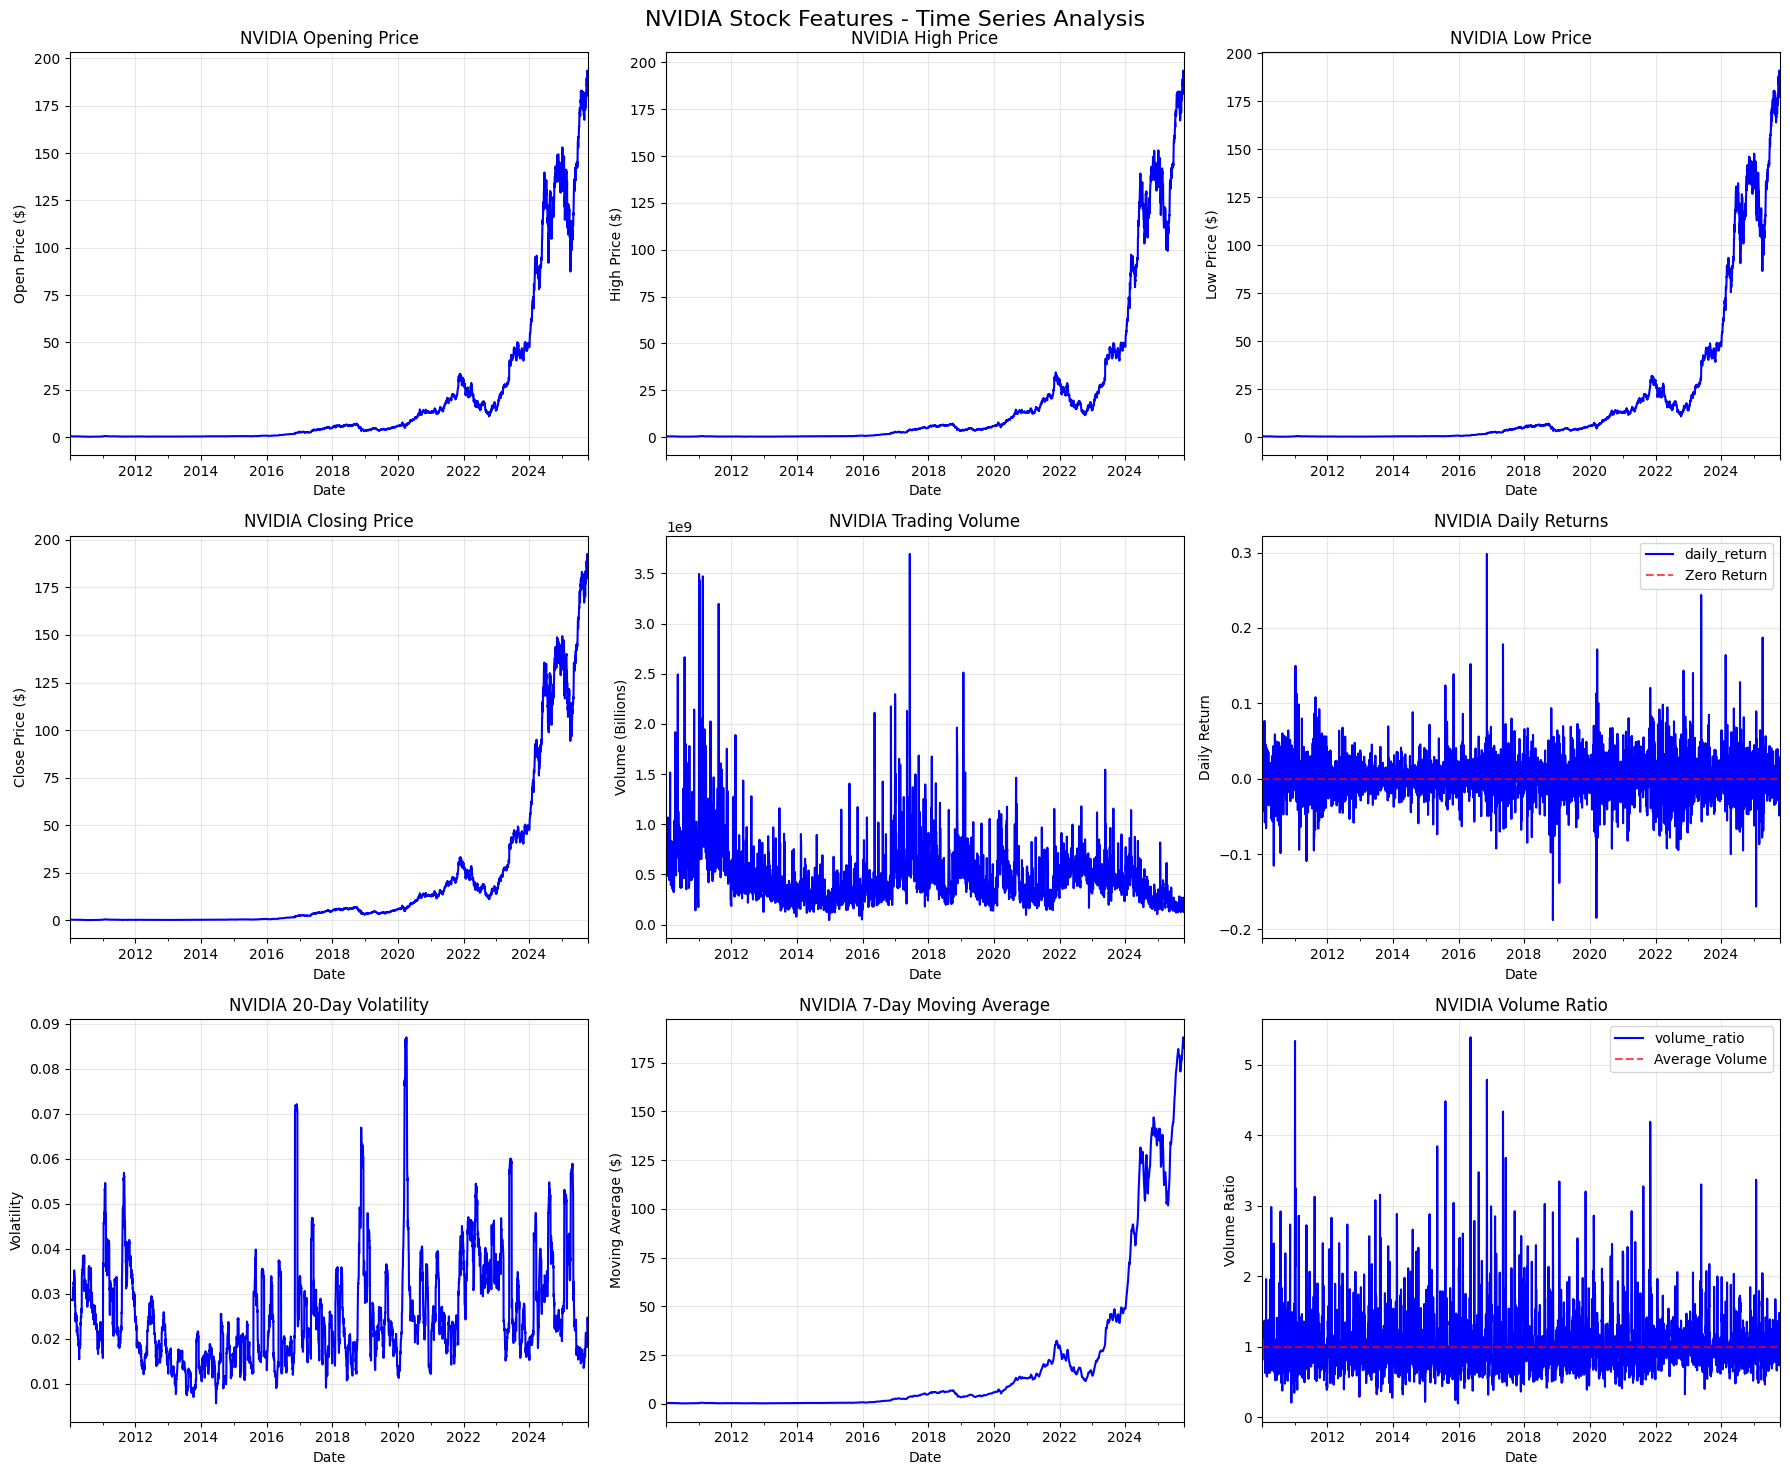

In [266]:
df_temp = df.copy()
df_temp.index = pd.to_datetime(df_temp.index, format='%d/%m/%Y')

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'volatility_20', 'moving_average', 'volume_ratio']
titles = ['NVIDIA Opening Price', 'NVIDIA High Price', 'NVIDIA Low Price', 'NVIDIA Closing Price', 
          'NVIDIA Trading Volume', 'NVIDIA Daily Returns', 'NVIDIA 20-Day Volatility', 
          'NVIDIA 7-Day Moving Average', 'NVIDIA Volume Ratio']
y_labels = ['Open Price ($)', 'High Price ($)', 'Low Price ($)', 'Close Price ($)', 
           'Volume (Billions)', 'Daily Return', 'Volatility', 'Moving Average ($)', 'Volume Ratio']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, (feature, title, y_label) in enumerate(zip(features, titles, y_labels)):
    df_temp[feature].plot(ax=axes[idx], title=title, color='blue')
    axes[idx].set_xlabel("Date")
    axes[idx].set_ylabel(y_label)
    axes[idx].grid(True, alpha=0.3)

    if feature == 'daily_return':
        axes[idx].axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Zero Return')
        axes[idx].legend()
    elif feature == 'volume_ratio':
        axes[idx].axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Average Volume')
        axes[idx].legend()

plt.suptitle('NVIDIA Stock Features - Time Series Analysis', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

* The price charts (Open, High, Low, Close, and Moving Average) show a dramatic upward trajectory, with prices remaining relatively stable until 2016-2017 before accelerating sharply, particularly from late 2020 onwards, reaching nearly $200 by early 2024. 
* The trading volume exhibits highly volatile patterns with significant spikes around 2010and 2017. 
* Daily returns fluctuate frequently around zero with extreme movements reaching up to +30% and down to -20%, highlighting some volatility. 
* The 20-day volatility plot confirms periods of increased price swings around 2017, 2019 and 2020. 

**3.3 Seasonal Decomposition**

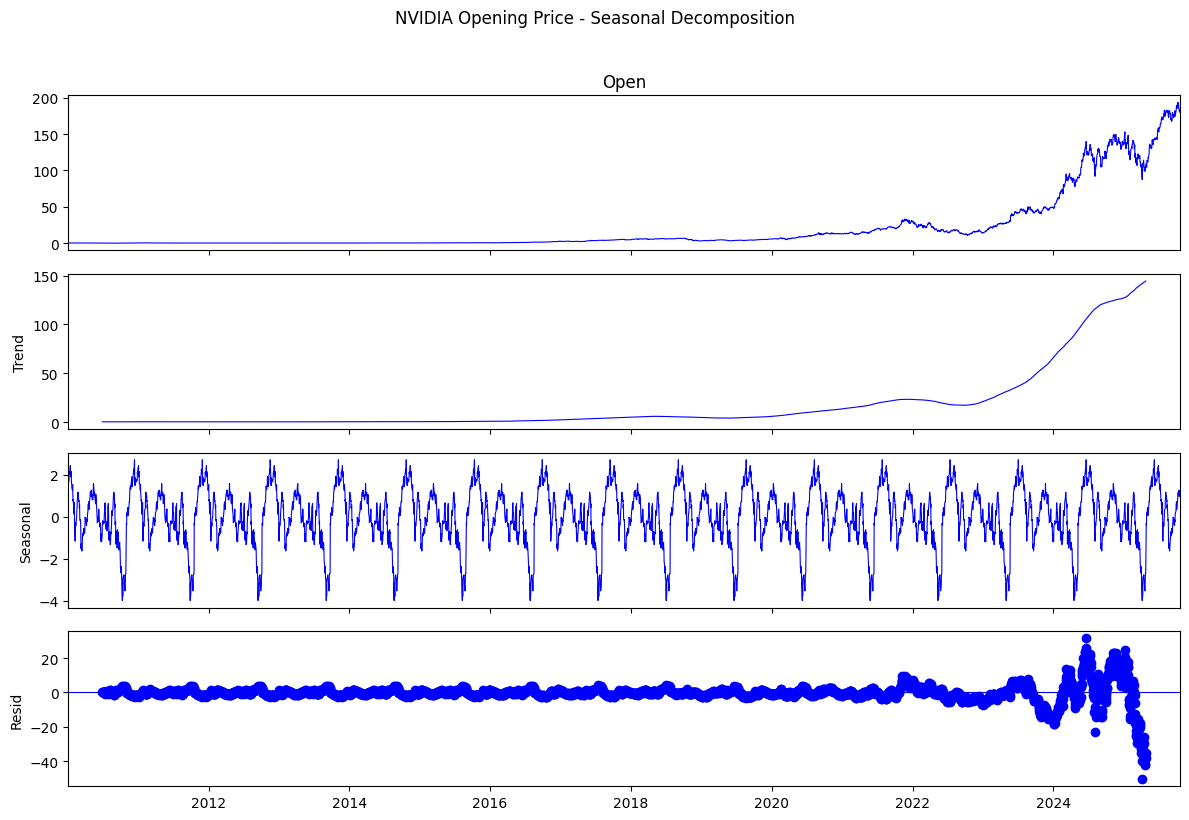

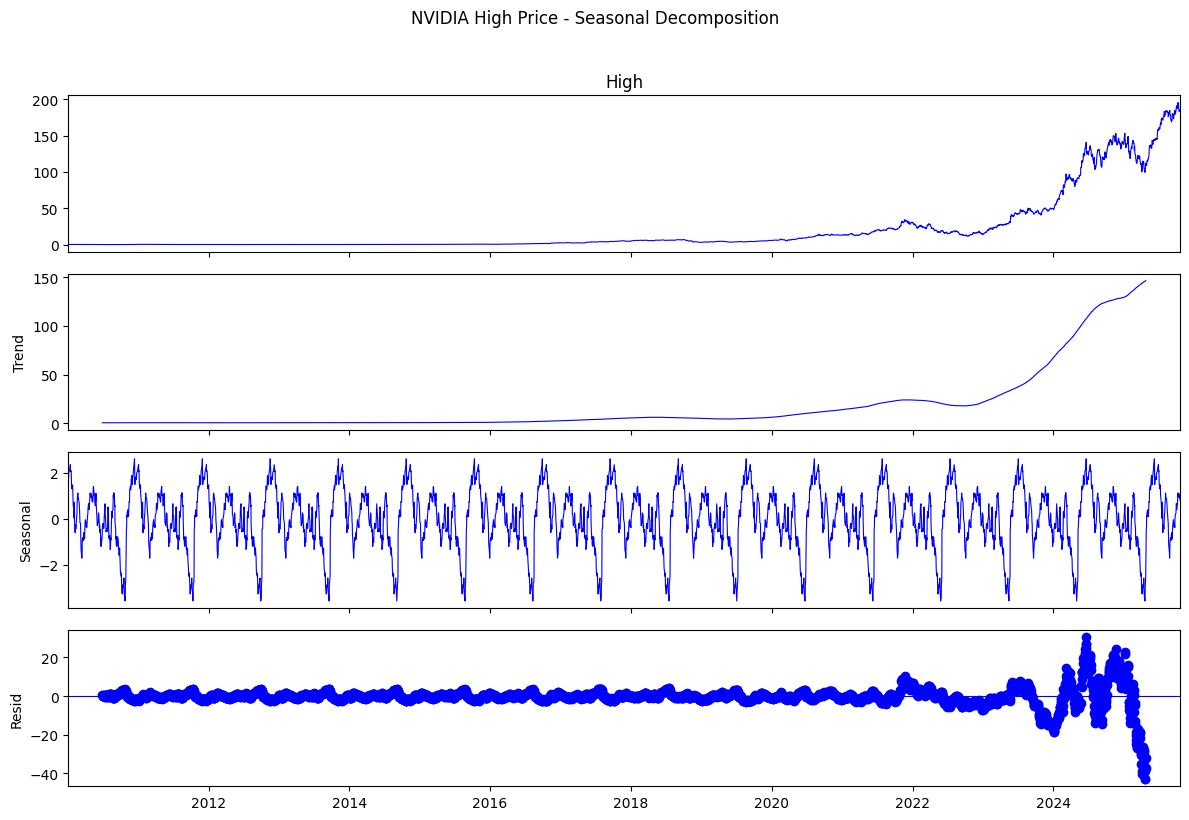

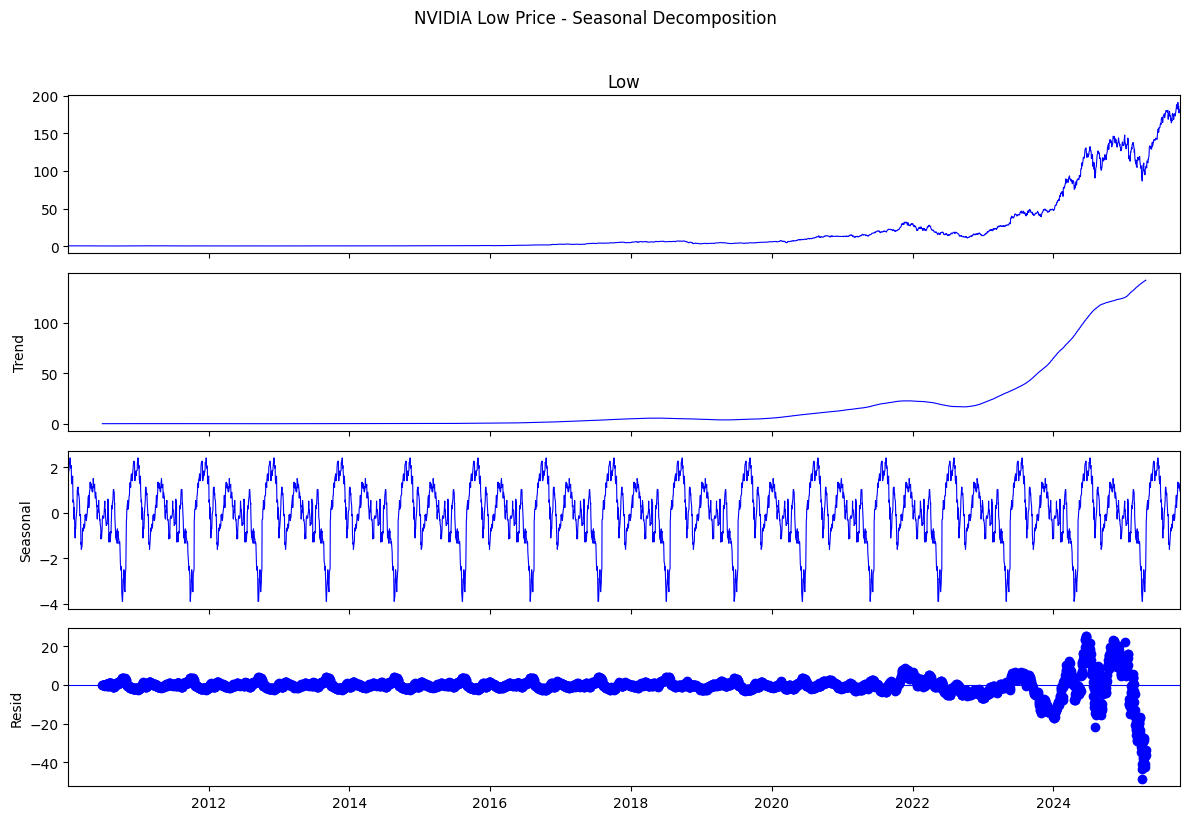

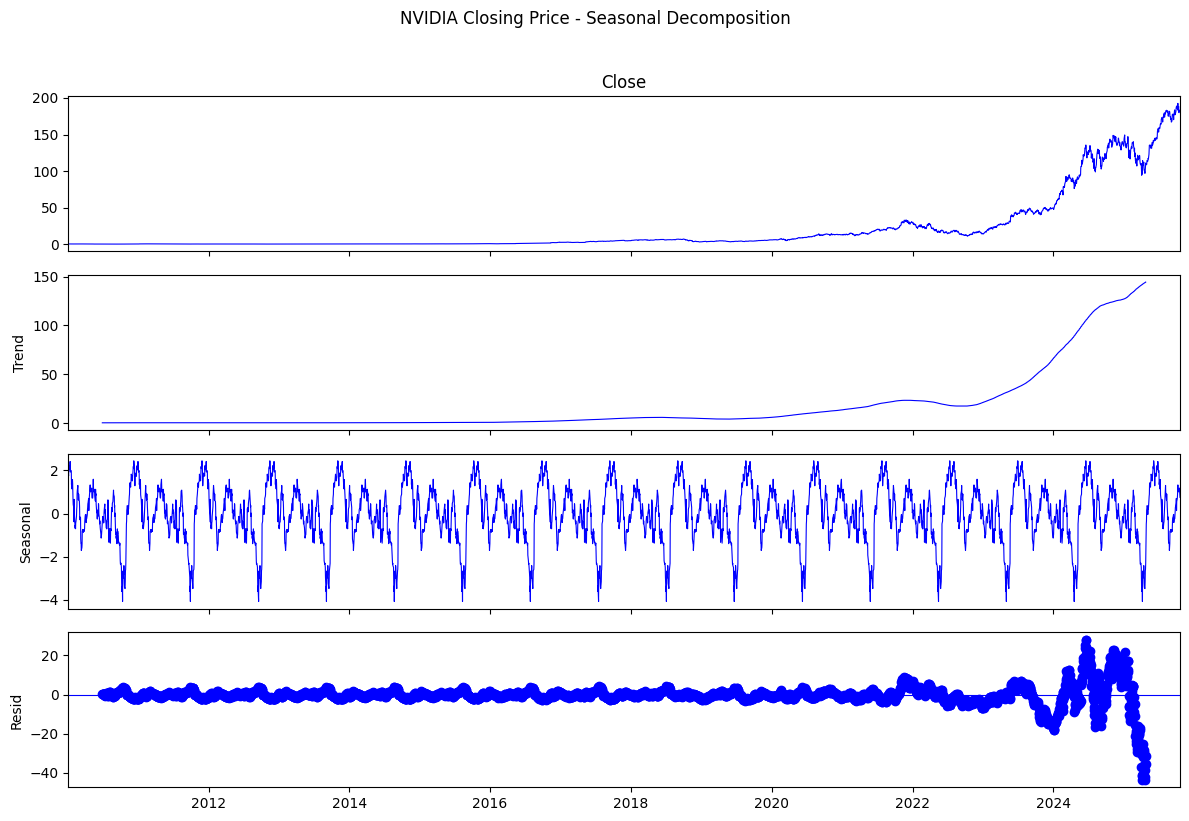

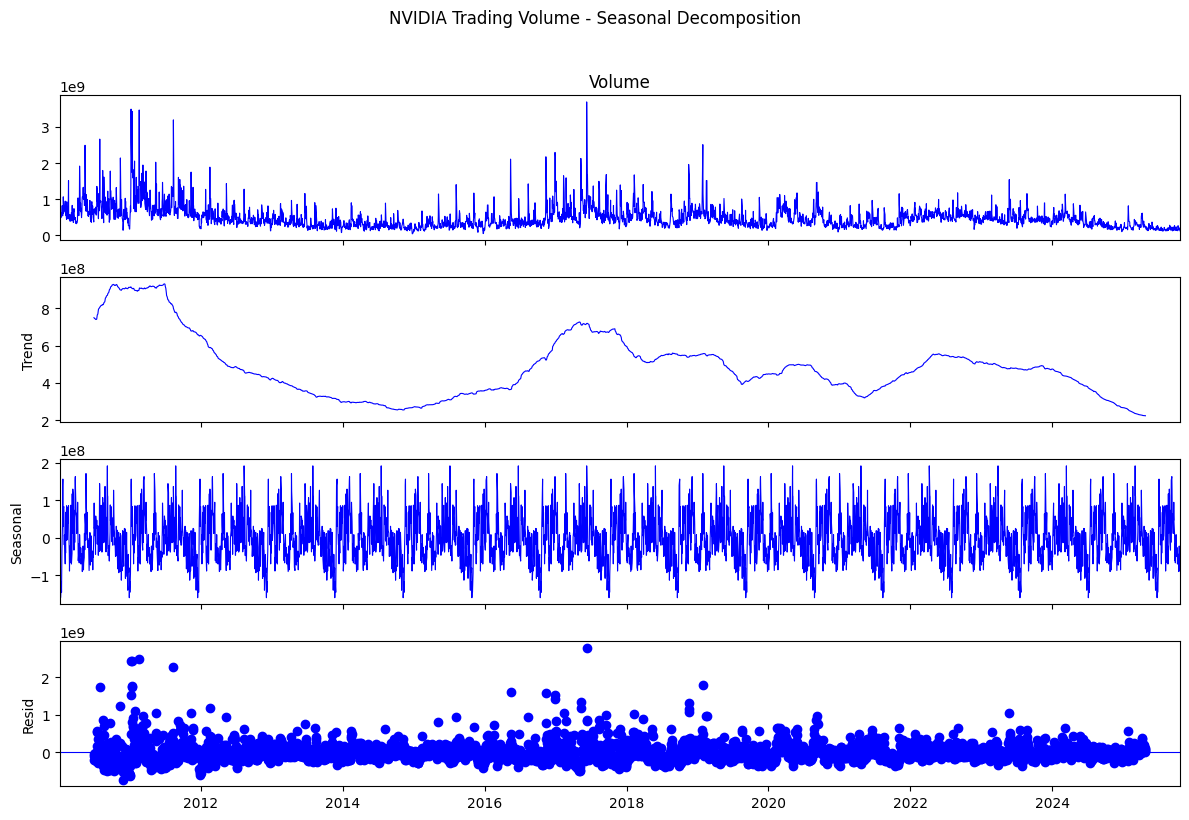

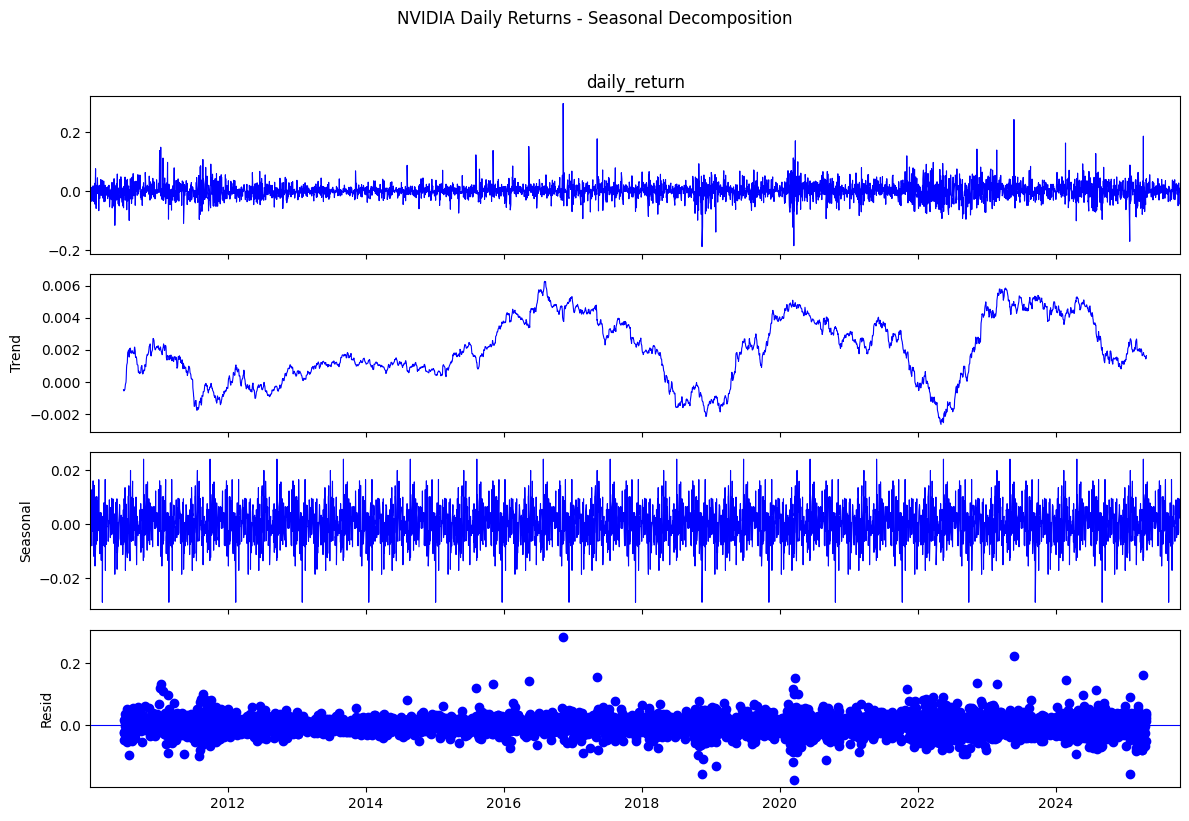

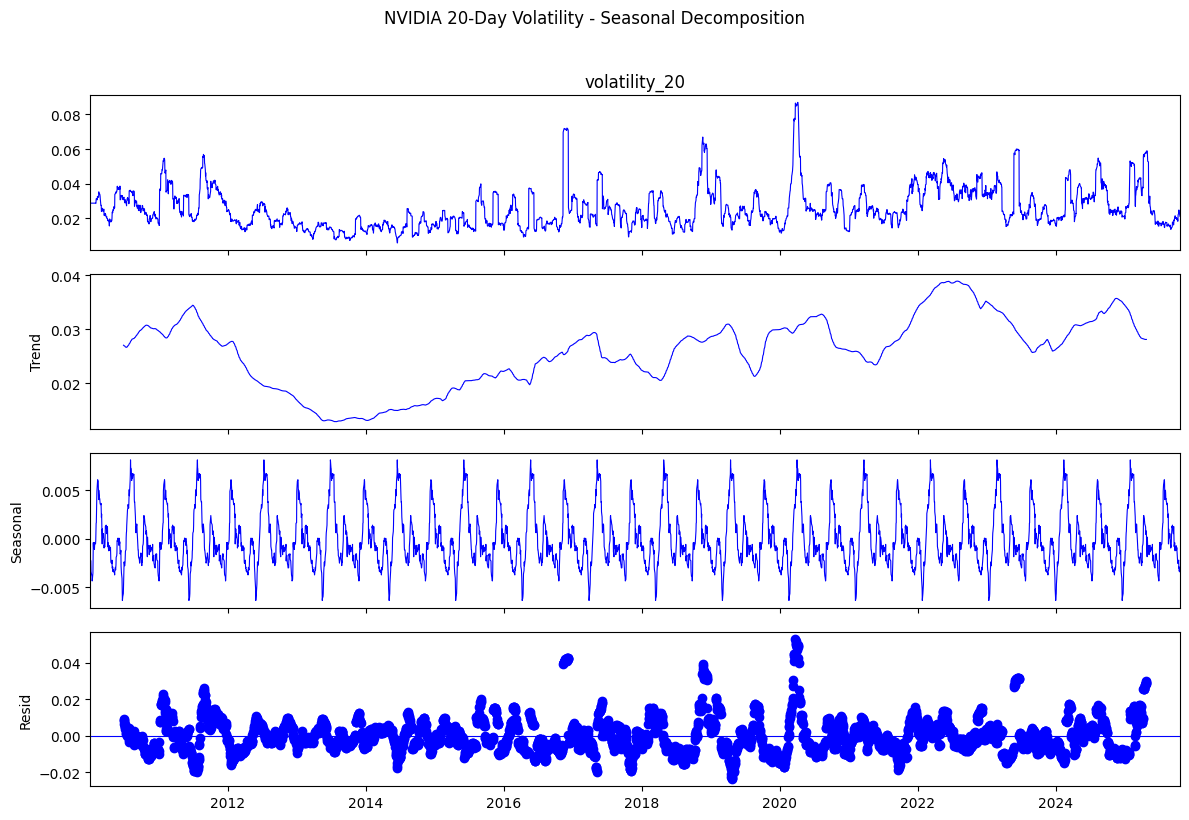

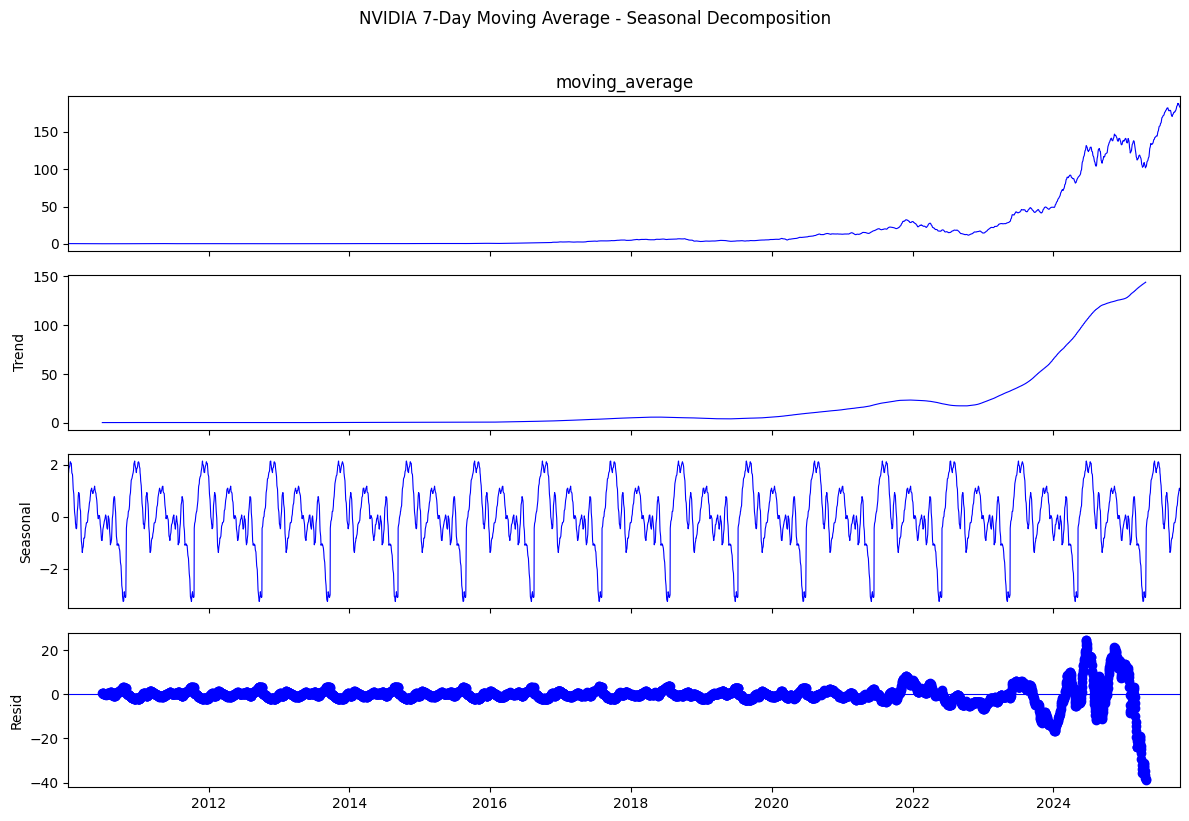

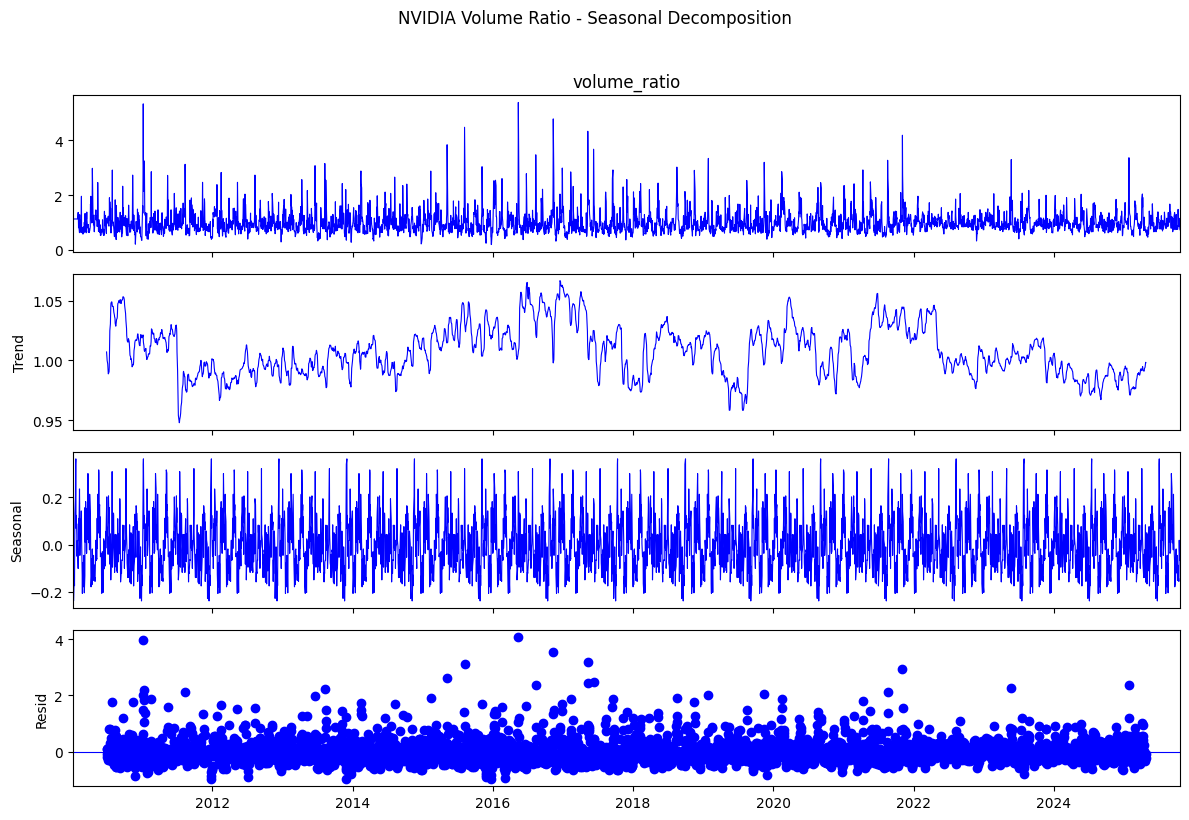

In [240]:
df_temp = df.copy()
df_temp.index = pd.to_datetime(df_temp.index, format='%d/%m/%Y')

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'volatility_20', 'moving_average', 'volume_ratio']
titles = ['NVIDIA Opening Price', 'NVIDIA High Price', 'NVIDIA Low Price', 'NVIDIA Closing Price', 
          'NVIDIA Trading Volume', 'NVIDIA Daily Returns', 'NVIDIA 20-Day Volatility', 
          'NVIDIA 7-Day Moving Average', 'NVIDIA Volume Ratio']

for feature, title in zip(features, titles):
    decomposition = seasonal_decompose(df_temp[feature], model='additive', period=252)
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    for ax in fig.get_axes():
        for line in ax.get_lines():
            line.set_linewidth(0.8)
            line.set_color('blue')
    
    plt.suptitle(f'{title} - Seasonal Decomposition', y=1.02)
    plt.tight_layout()
    plt.show()

**Trend**: NVIDIA's gradual growth from 2010-2016, then explosive growth from 2020-2024, showing the fundamental upward movement after removing daily noise and seasonal effects.

**Seasonal**: Repeating annual patterns, consistent oscillations (like -3 to +2 for prices, -0.2 to +0.2 for volume ratio) that happen every year. 

**Residuals**: The unpredictable "noise" left after removing trend and seasonal effects, these represent random events, unexpected news, or anomalies that can't be predicted by regular patterns. 


**3.4 Distribution Analysis**

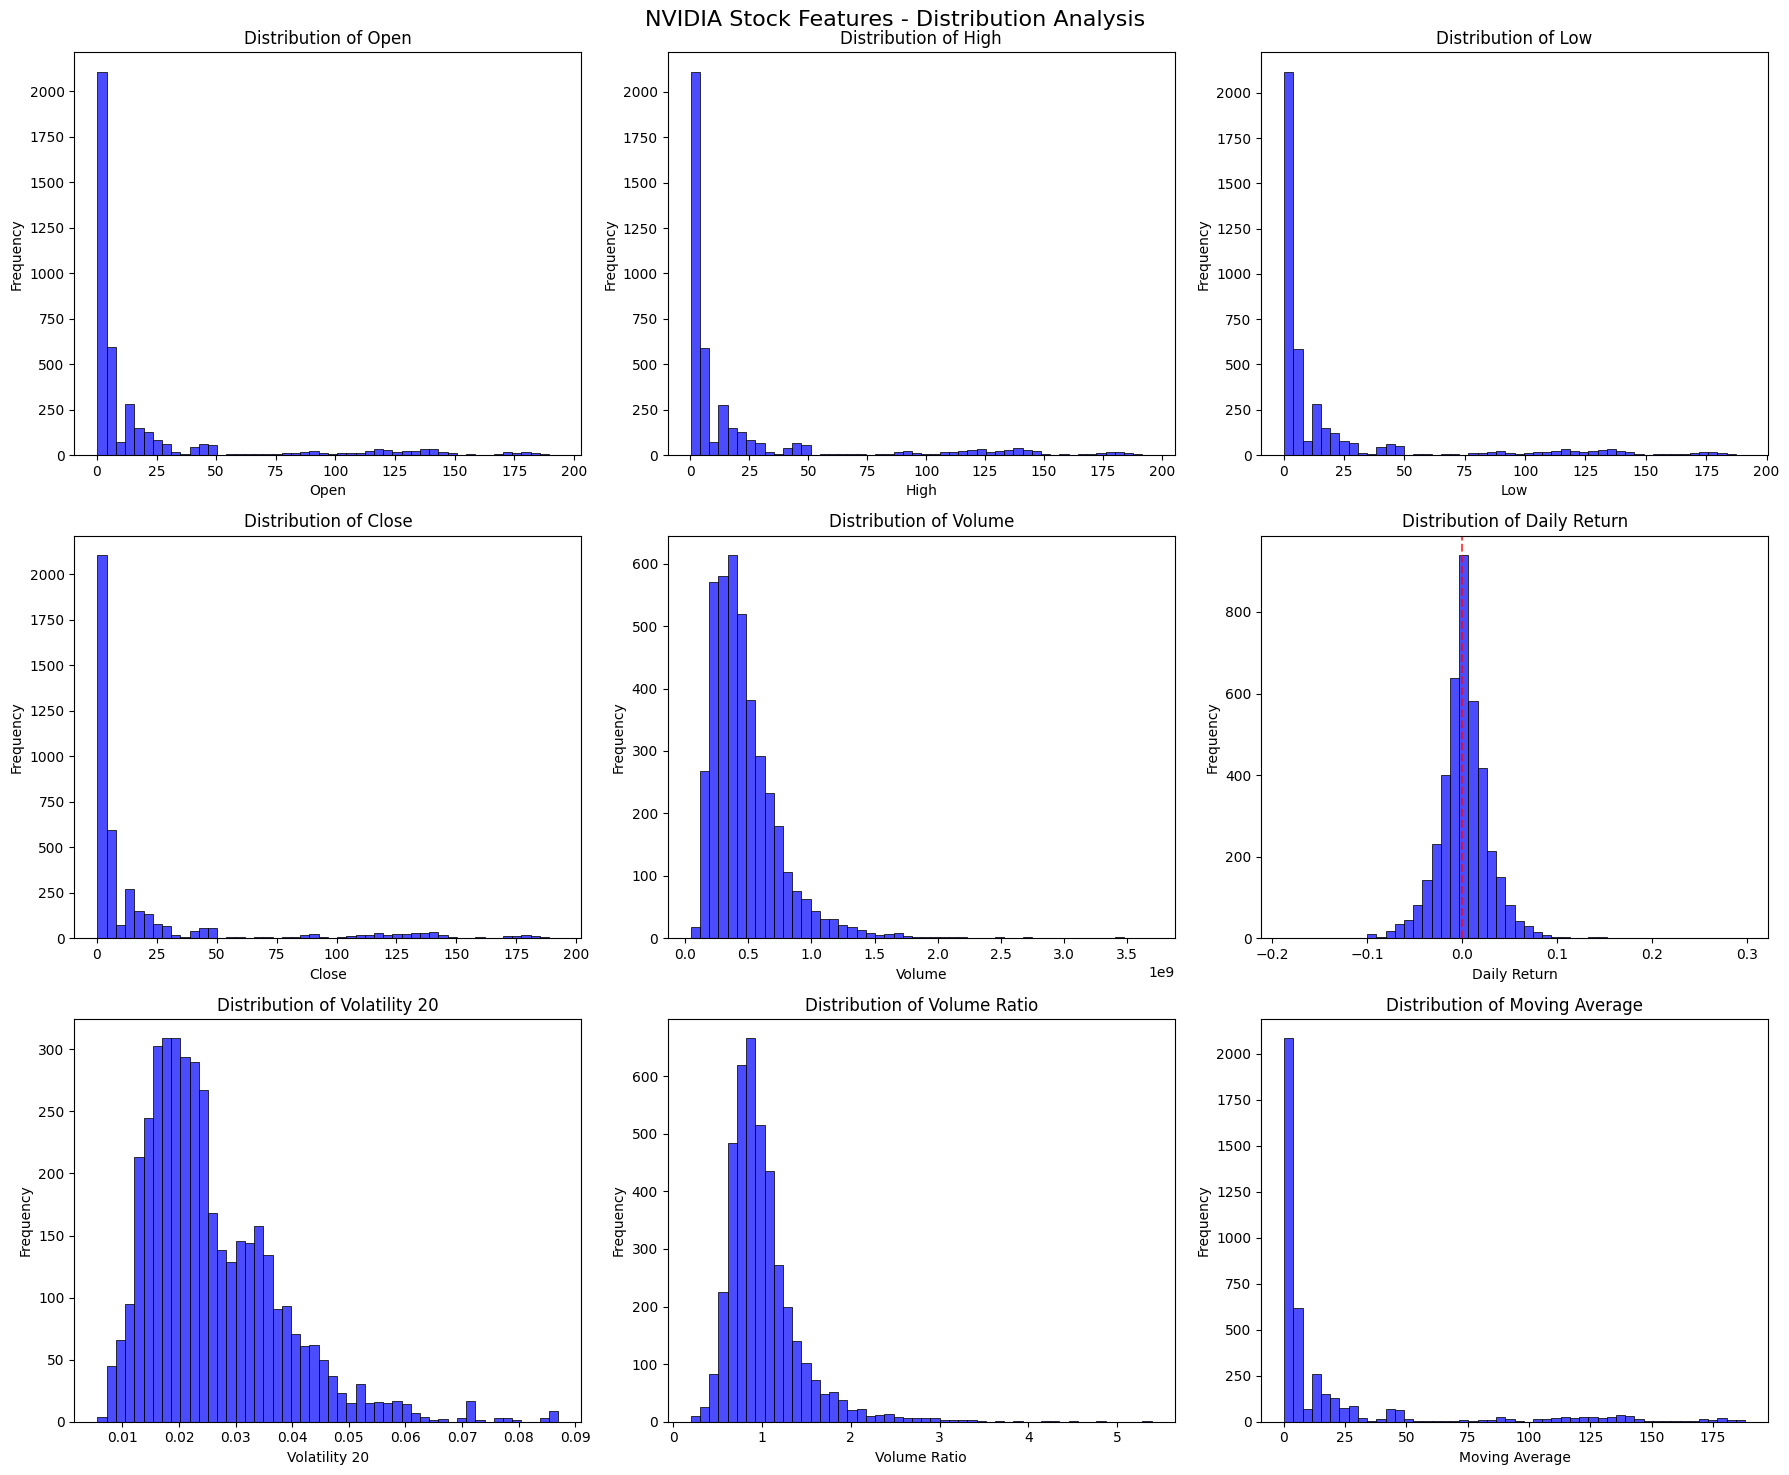

In [239]:
numerical_features = ['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'volatility_20', 'volume_ratio', 'moving_average']
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    if feature == 'daily_return':
        sns.histplot(df[feature], bins=50, alpha=0.7, ax=axes[idx], color='blue')
        axes[idx].axvline(0, color='red', linestyle='--', alpha=0.7)
    else:
        sns.histplot(df[feature], bins=50, alpha=0.7, ax=axes[idx], color='blue')
    
    axes[idx].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[idx].set_xlabel(feature.replace("_", " ").title())
    axes[idx].set_ylabel('Frequency')

plt.suptitle('NVIDIA Stock Features - Distribution Analysis', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

**Price distributions (Open, High, Low, Close, Moving Average)**: Strongly right-skewed, with most observations in the 0–25 range and a long tail extending toward 200. This reflects NVIDIA’s history at lower prices and recent price acceleration.

**Volume**: Right-skewed, with most days in the 0–0.5 billion range and occasional spikes up to 3.5 billion. 

**Daily return**: Approximately bell-shaped, centered around 0 (marked by a red dashed line), ranging from -0.2 to +0.3. 

**20-day volatility**: Right-skewed, with a peak around 0.02 (2%), a smaller concentration around 0.01, and a range up to 0.09, showing periods of both low and high volatility.

**Volume ratio**: Right-skewed, with the highest frequency near 0–1.0 and a tail extending to 5.0, indicating most days are near or below average, with some days of significantly elevated volume.

**3.5 Anomaly Detection**

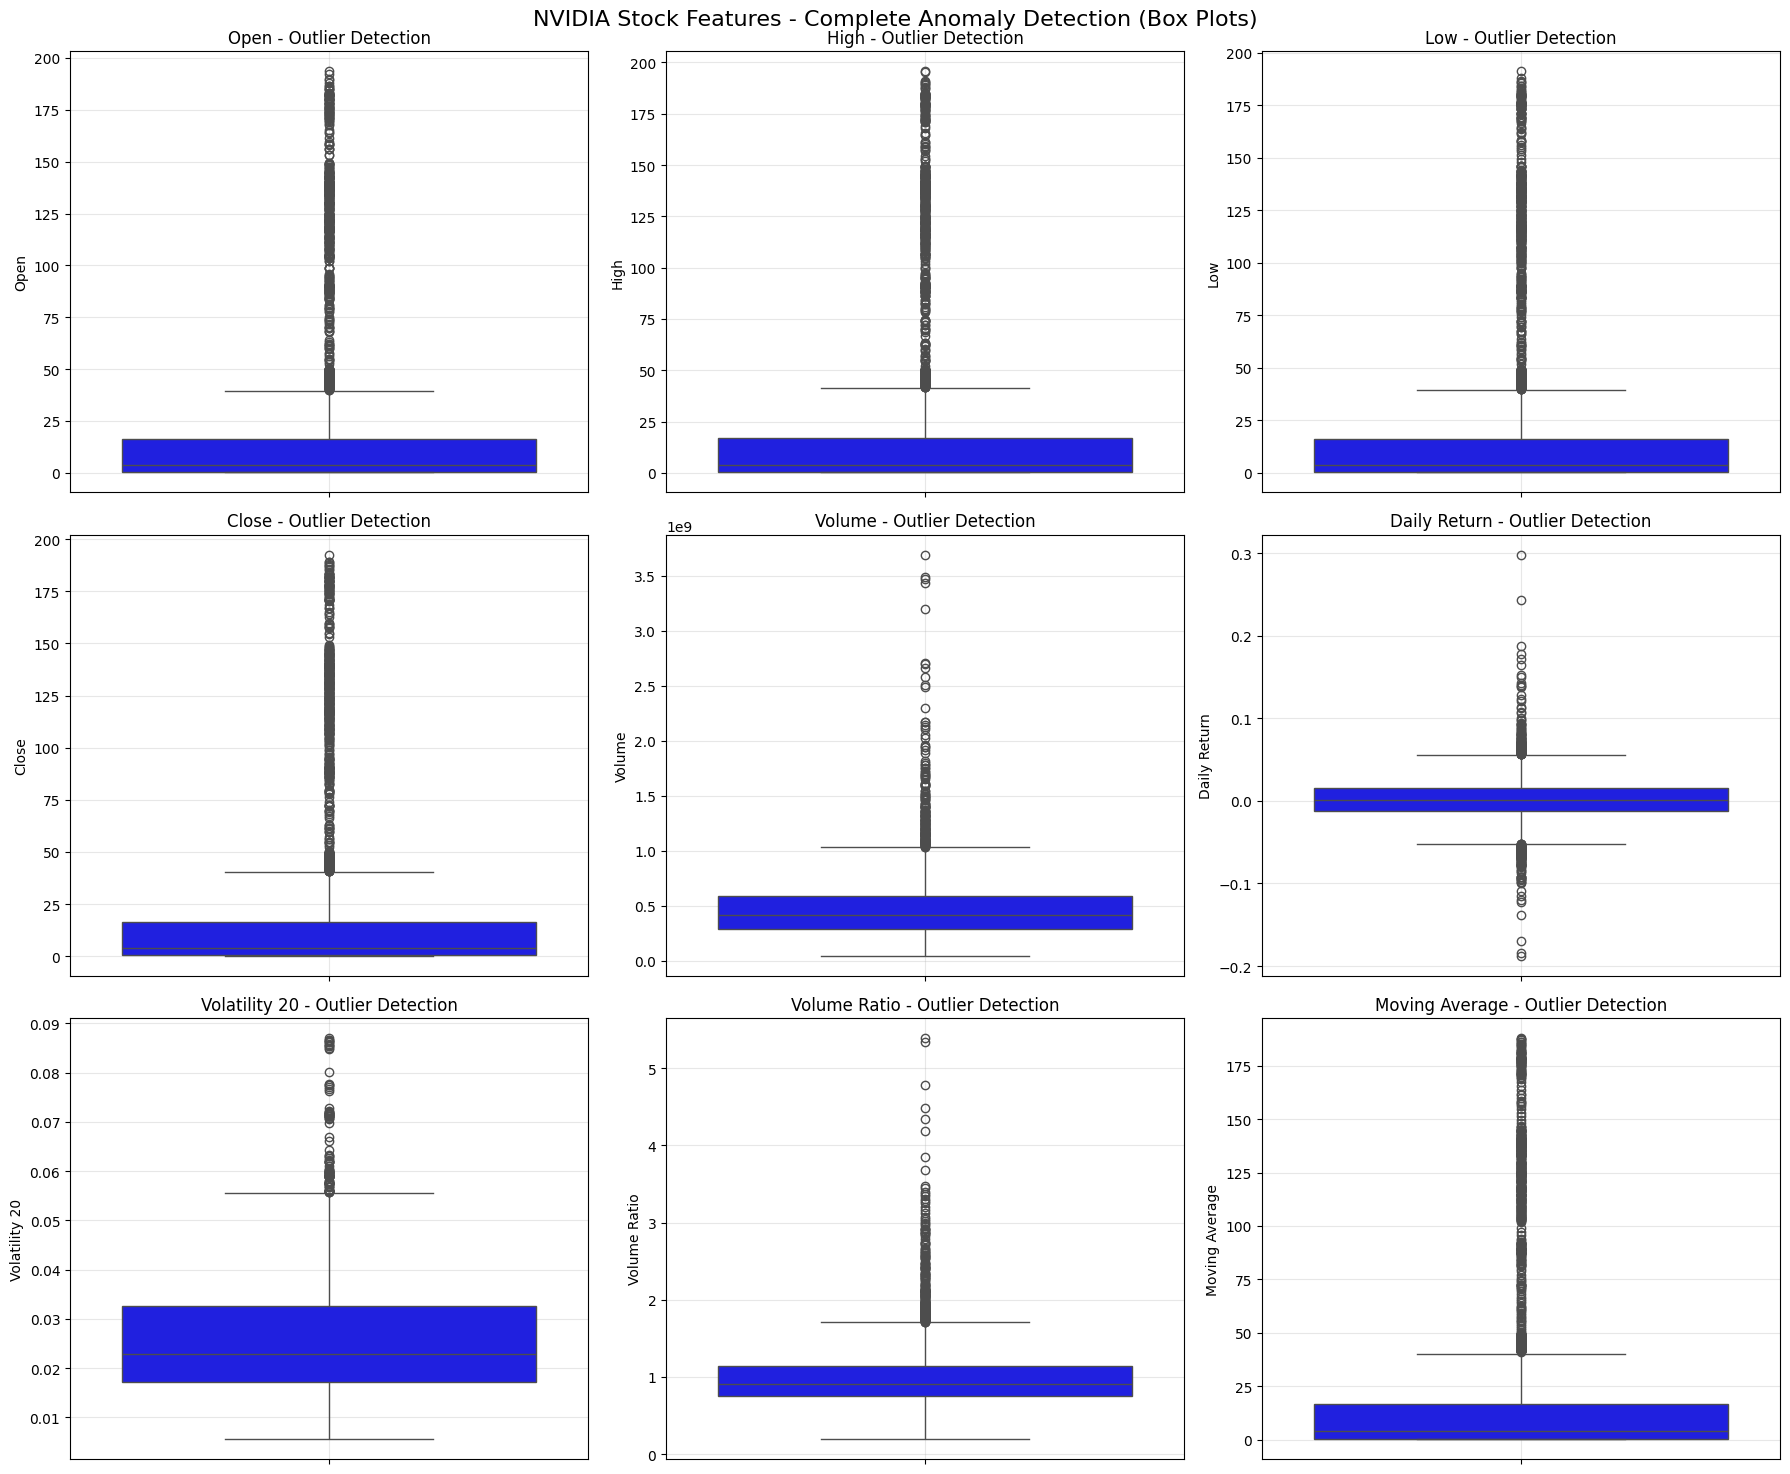

In [ ]:
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'volatility_20', 'volume_ratio', 'moving_average']
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()
for idx, feature in enumerate(features):
    sns.boxplot(data=df[feature], ax=axes[idx], color='blue')
    axes[idx].set_title(f'{feature.replace("_", " ").title()} - Outlier Detection')
    axes[idx].set_ylabel(feature.replace("_", " ").title())
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('NVIDIA Stock Features - Complete Anomaly Detection (Box Plots)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

It seems in most cases, we have a significant number of outliers for all features. I will now look into this more deeply with more of an advanced anomaly detection methods below (Isolaiton Forest and Local Outlier Factor).

Isolation Forest found 206 anomalies
Local Outlier Factor found 206 anomalies


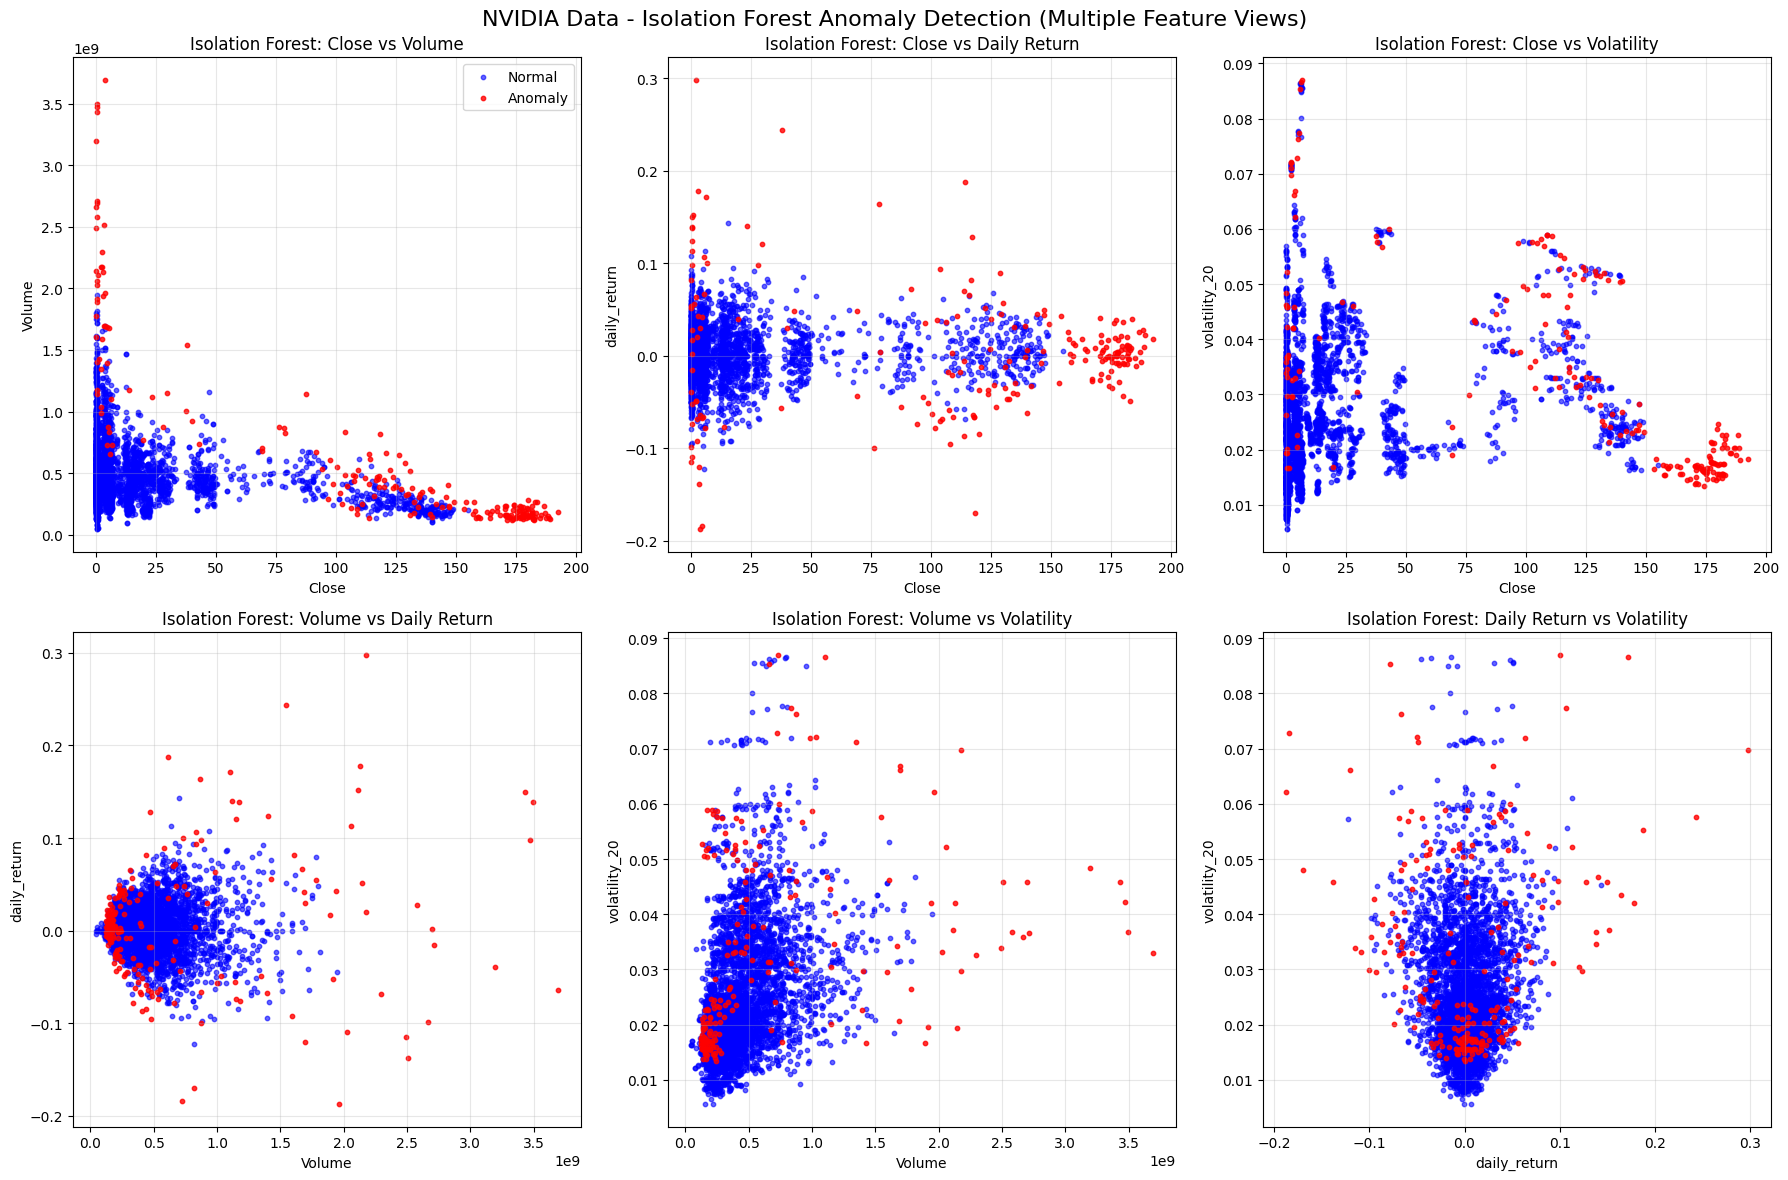

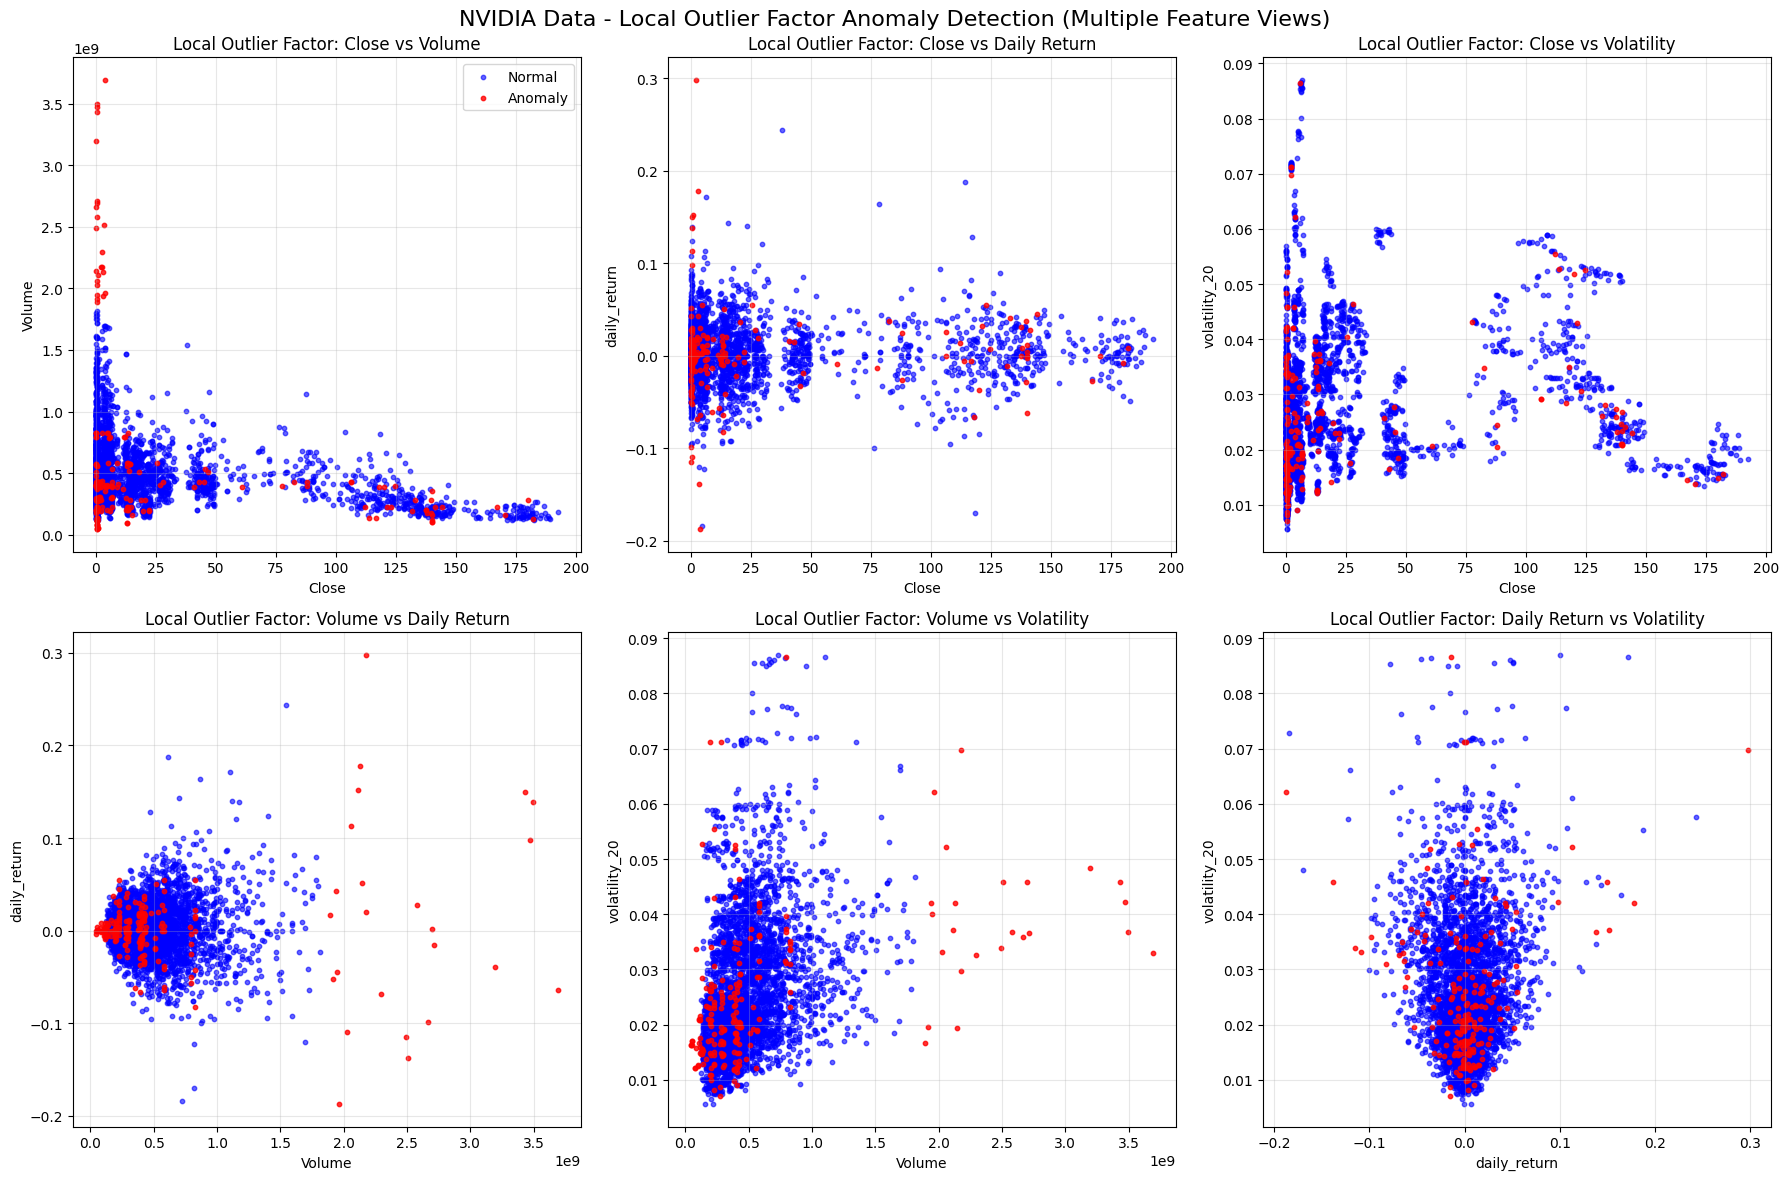

In [387]:
features_for_anomaly = ['Close', 'Volume', 'daily_return', 'volatility_20', 'volume_ratio', 'moving_average']
X = df[features_for_anomaly].values

iso = IsolationForest(contamination=0.05, random_state=42)
y_pred_iso = iso.fit_predict(X)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred_lof = lof.fit_predict(X)

df['isolation_forest_anomaly'] = y_pred_iso
df['lof_anomaly'] = y_pred_lof

print(f"Isolation Forest found {sum(y_pred_iso == -1)} anomalies")
print(f"Local Outlier Factor found {sum(y_pred_lof == -1)} anomalies")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

feature_pairs = [
    (0, 1, 'Close vs Volume'),
    (0, 2, 'Close vs Daily Return'),
    (0, 3, 'Close vs Volatility'),
    (1, 2, 'Volume vs Daily Return'),
    (1, 3, 'Volume vs Volatility'),
    (2, 3, 'Daily Return vs Volatility')
]

for idx, (feat1, feat2, title) in enumerate(feature_pairs):
    axes[idx].scatter(X[y_pred_iso == 1, feat1], X[y_pred_iso == 1, feat2], 
                     c='blue', s=10, label='Normal', alpha=0.6)
    axes[idx].scatter(X[y_pred_iso == -1, feat1], X[y_pred_iso == -1, feat2], 
                     c='red', s=10, label='Anomaly', alpha=0.8)
    axes[idx].set_title(f'Isolation Forest: {title}')
    axes[idx].set_xlabel(features_for_anomaly[feat1])
    axes[idx].set_ylabel(features_for_anomaly[feat2])
    axes[idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[idx].legend()

plt.suptitle('NVIDIA Data - Isolation Forest Anomaly Detection (Multiple Feature Views)', 
             fontsize=16, y=0.98)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (feat1, feat2, title) in enumerate(feature_pairs):
    axes[idx].scatter(X[y_pred_lof == 1, feat1], X[y_pred_lof == 1, feat2], 
                     c='blue', s=10, label='Normal', alpha=0.6)
    axes[idx].scatter(X[y_pred_lof == -1, feat1], X[y_pred_lof == -1, feat2], 
                     c='red', s=10, label='Anomaly', alpha=0.8)
    axes[idx].set_title(f'Local Outlier Factor: {title}')
    axes[idx].set_xlabel(features_for_anomaly[feat1])
    axes[idx].set_ylabel(features_for_anomaly[feat2])
    axes[idx].grid(True, alpha=0.3)
    if idx == 0:
        axes[idx].legend()

plt.suptitle('NVIDIA Data - Local Outlier Factor Anomaly Detection (Multiple Feature Views)', 
             fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

* **Normal days (blue points)**: Most days cluster in expected regions: lower prices (below $50), moderate volume (below 1 billion), daily returns near zero, and lower volatility (2-5%). 

* **Anomalous days (red points)**: Days that deviate from normal patterns (206 anomalies identified). 

These represent real market events and are important for identifying market regimes, so I plan to keep these outliers. 

**3.6 Correlation Matrix**

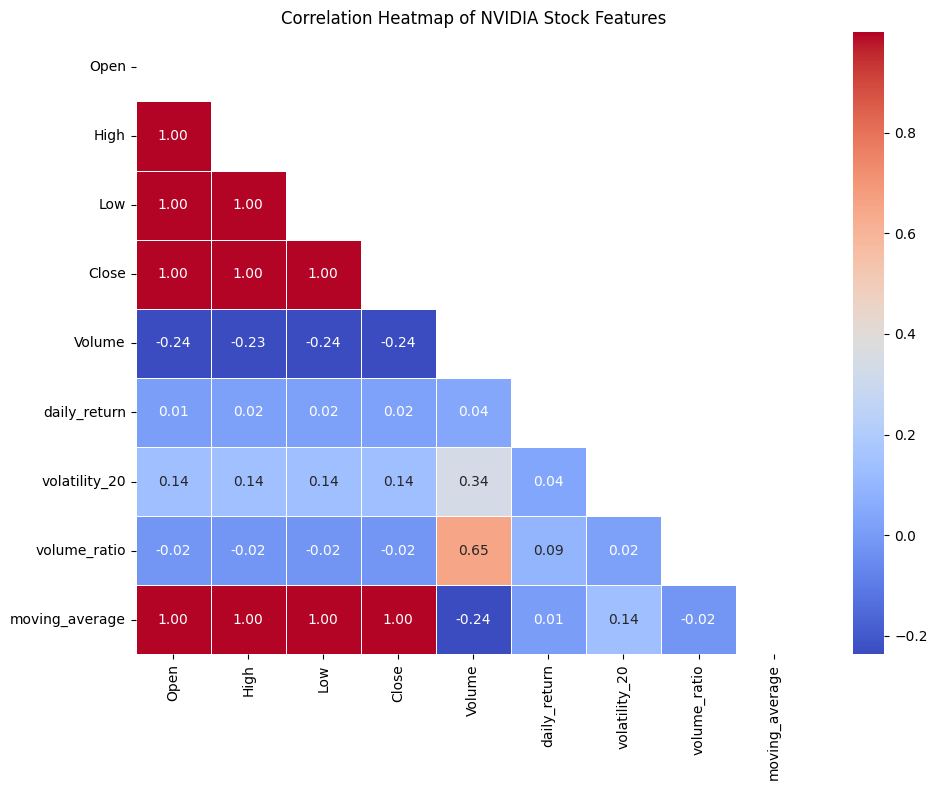

In [236]:
orig_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'volatility_20', 'volume_ratio', 'moving_average']
corr_matrix = df[orig_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of NVIDIA Stock Features')
plt.tight_layout()
plt.show()

* Open, High, Low, Close, and moving_average are nearly perfectly correlated (≈1.00), which is expected since they’re all price-based and move together. 
* Volume shows a slight negative correlation with price features (-0.23 to -0.24), suggesting higher volumes often coincide with slight price declines or that price increases occur on lower volume days. 
* Daily returns have very weak correlations with most features (0.01–0.02).
* Volume_ratio shows a moderate positive correlation with Volume (0.65) as expected.
* Volatility_20 shows moderate correlation with Volume (0.34), suggesting higher trading volume can accompany increased price volatility. 

### 4. UNSUPERVISED LEARNING

**4.1 Feature Scaling**

In [369]:
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'volatility_20', 'volume_ratio', 'moving_average']
X = df[features].values
X_scaled = MinMaxScaler().fit_transform(X)

Feature scaling transforms all features to a common range (0–1 for MinMaxScaler) so that features with different scales don't dominate distance calculations in clustering algorithms. 

**4.2 Elbow Method**

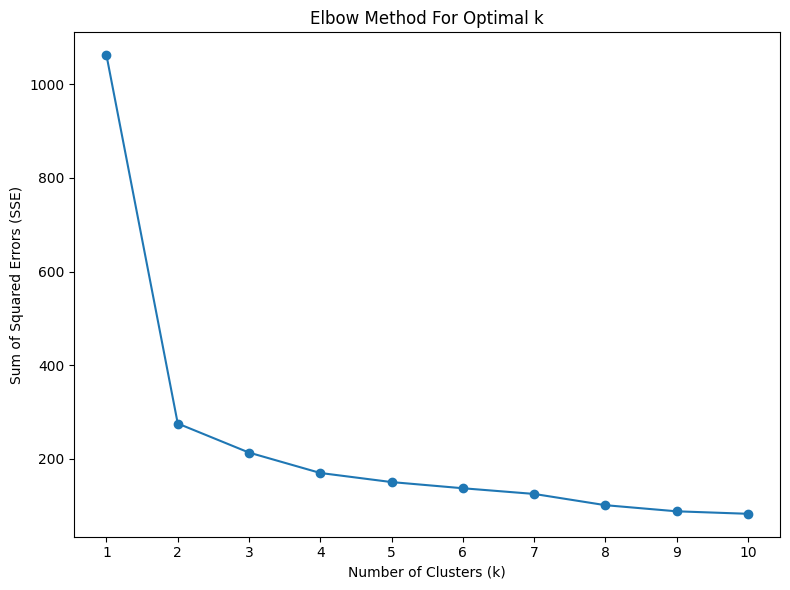

In [370]:
sse = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K, sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method For Optimal k')
plt.xticks(K)
plt.tight_layout()
plt.show()

* The Elbow Method plot for K-means shows a sharp drop from k=1 (SSE ~1050) to k=2 (SSE ~270), then a further drop to k=3 (SSE ~210), after which the curve flattens with smaller decreases for k≥4. 
* **k=3 was chosen** because there is a substantial improvement from k=2 to k=3, showing meaningful separation that justifies the additional cluster and the curve starts to flatten after k=3, indicating diminishing returns beyond this point. 

**4.3 Clustering**

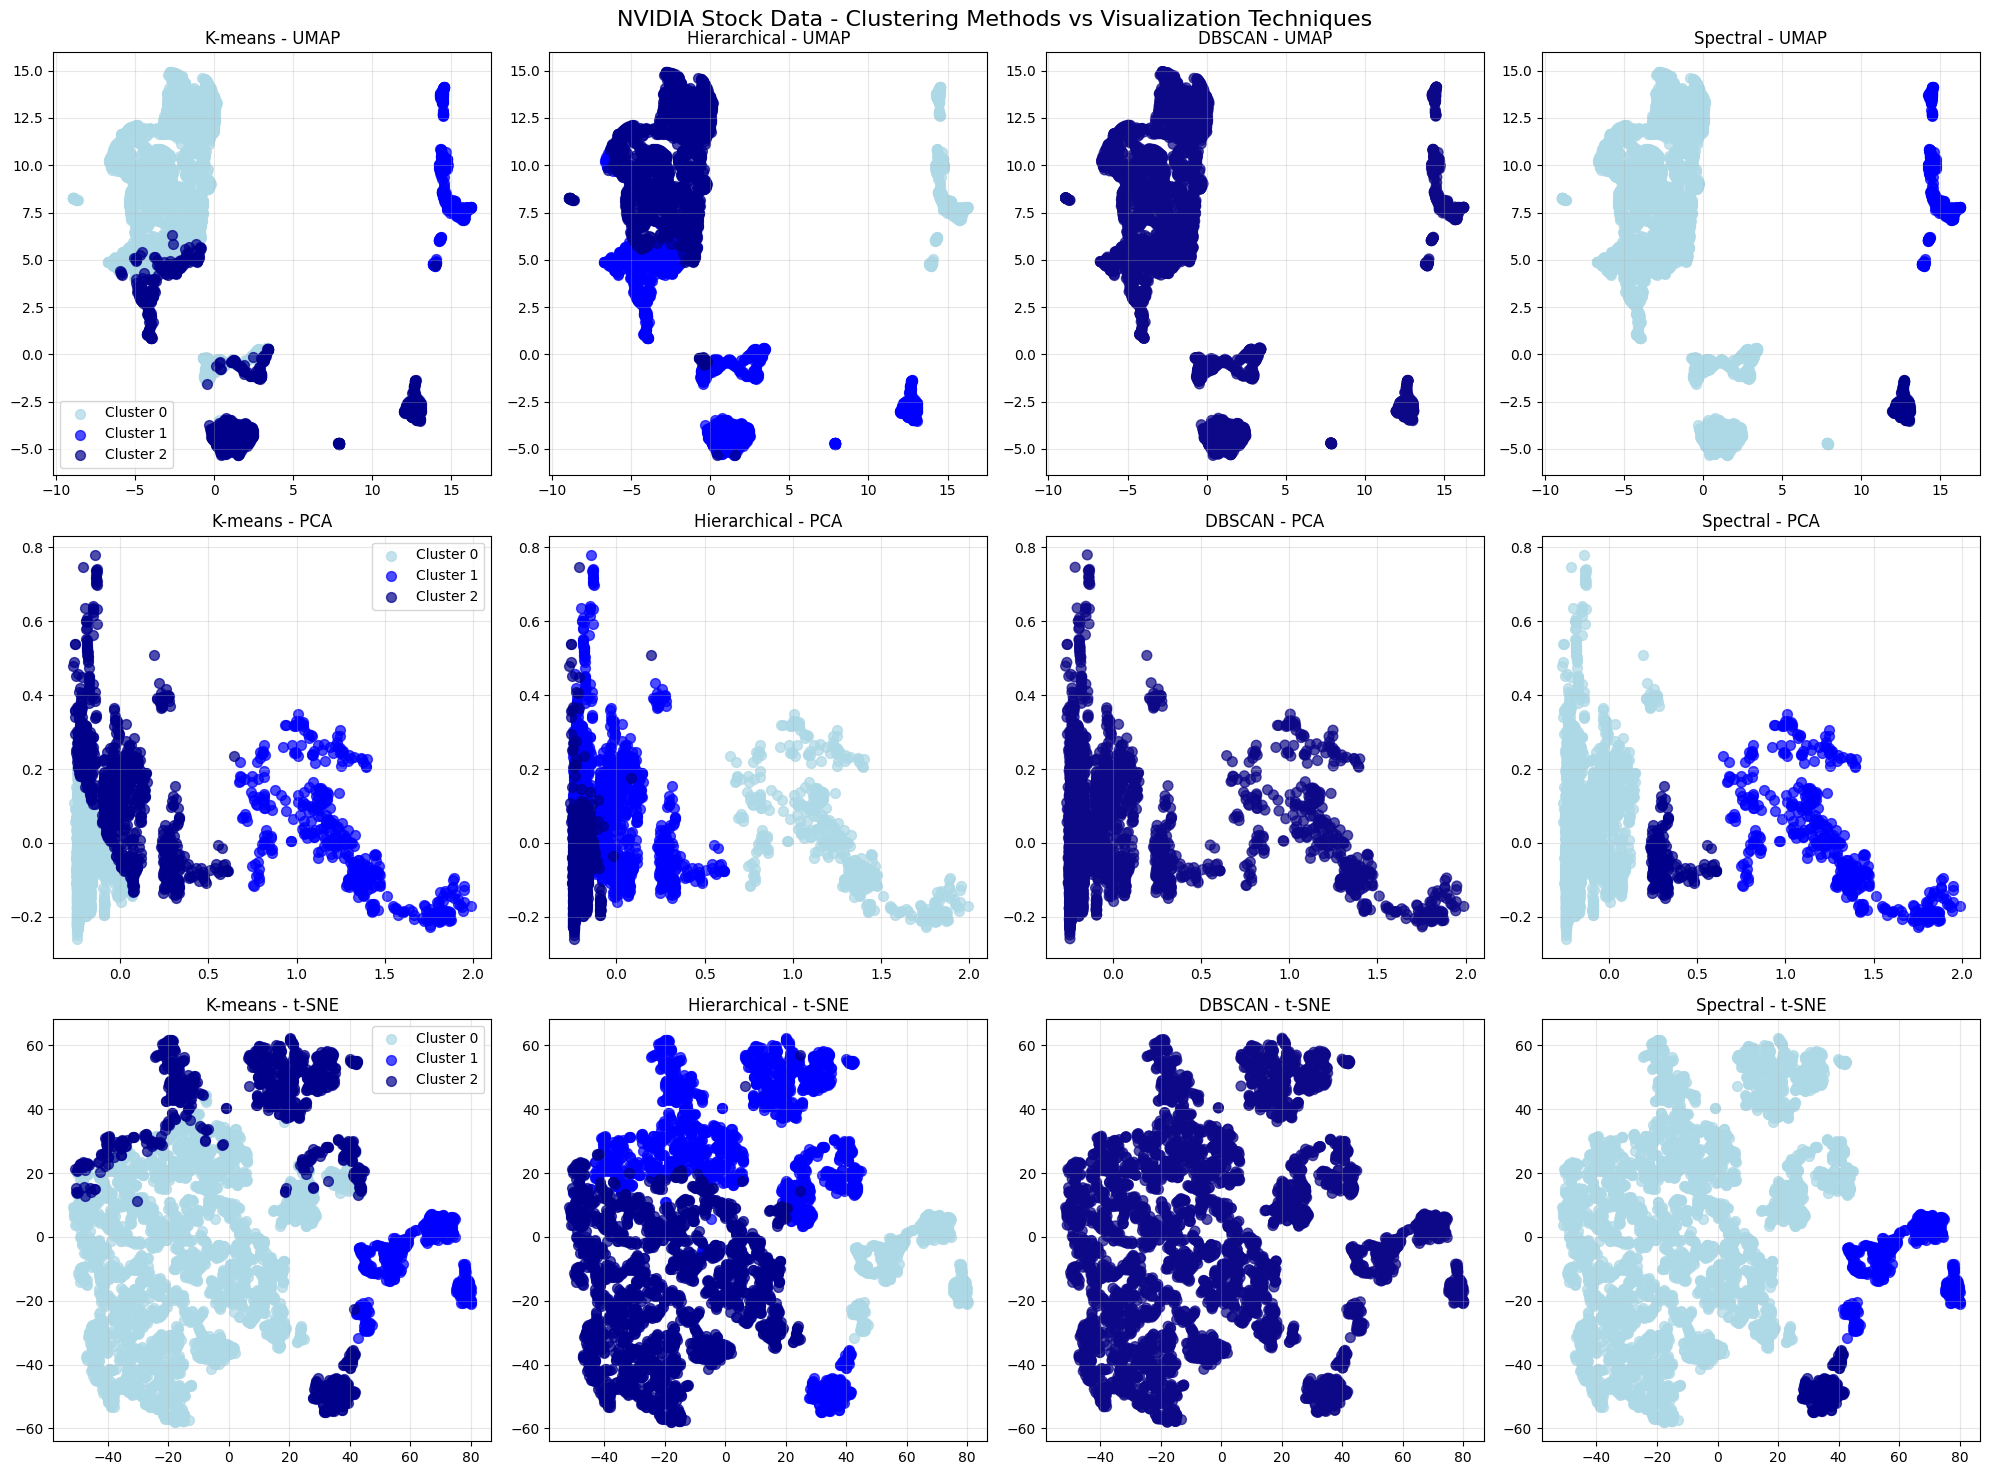

In [ ]:
warnings.filterwarnings('ignore')
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

dbscan = DBSCAN(eps=5, min_samples=70)
dbscan_labels = dbscan.fit_predict(X_scaled)

spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', 
                             n_neighbors=10, assign_labels='kmeans', random_state=42)
spectral_labels = spectral.fit_predict(X_scaled)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
colors = ['lightblue', 'blue', 'darkblue']
clustering_methods = [('K-means', kmeans_labels), ('Hierarchical', hierarchical_labels), 
                     ('DBSCAN', dbscan_labels), ('Spectral', spectral_labels)]
visualization_methods = [('UMAP', X_umap), ('PCA', X_pca), ('t-SNE', X_tsne)]

for row, (viz_name, X_viz) in enumerate(visualization_methods):
    for col, (clust_name, clust_labels) in enumerate(clustering_methods):
        ax = axes[row, col]
        
        if clust_name == 'DBSCAN':
            ax.scatter(X_viz[:, 0], X_viz[:, 1], c=clust_labels, cmap='plasma', s=50, alpha=0.7)
        else:
            for i, cluster_label in enumerate([0, 1, 2]):
                mask = clust_labels == cluster_label
                ax.scatter(X_viz[mask, 0], X_viz[mask, 1], 
                          c=colors[i], label=f'Cluster {cluster_label}', s=50, alpha=0.7)
            if col == 0:
                ax.legend()
        
        ax.set_title(f'{clust_name} - {viz_name}')
        ax.grid(True, alpha=0.3)

plt.suptitle('NVIDIA Stock Data - Clustering Methods vs Visualization Techniques', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

* This grid compares four clustering methods (K-means, Hierarchical, DBSCAN, Spectral) using three dimensionality reduction techniques (UMAP, PCA, t-SNE) to visualize how each algorithm groups NVIDIA's stock data into three clusters (0, 1, 2) when projected into two dimensions. 
* Each plot shows data points colored by cluster assignment (light blue, blue, dark blue) to illustrate the similarity and differences between clustering approaches across different visualisation perspectives, helping identify which method provides the clearest and most interpretable separation of market regimes.
* Spectral Clustering shows the clearest separation, with three distinct, well-separated clusters. K-means shows similar structure but with less clear separation. Hierarchical shows overlapping clusters and DBSCAN fails to find valid clusters. 

**4.4 Evaluation**

In [378]:

algorithms = ['K-means', 'Hierarchical', 'DBSCAN', 'Spectral']
labels = [kmeans_labels, hierarchical_labels, dbscan_labels, spectral_labels]

for name, cluster_labels in zip(algorithms, labels):
    if len(set(cluster_labels)) > 1: 
        silhouette = silhouette_score(X_scaled, cluster_labels)
        davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)
        n_clusters = len(set(cluster_labels))
        
        print(f"{name}:")
        print(f"  Silhouette Score: {silhouette:.3f}")
        print(f"  Davies-Bouldin Index: {davies_bouldin:.3f}")
        print(f"  Number of clusters: {n_clusters}")
        print()
    else:
        print(f"{name}: No valid clusters found")
        print()

K-means:
  Silhouette Score: 0.431
  Davies-Bouldin Index: 1.050
  Number of clusters: 3

Hierarchical:
  Silhouette Score: 0.340
  Davies-Bouldin Index: 1.101
  Number of clusters: 3

DBSCAN: No valid clusters found

Spectral:
  Silhouette Score: 0.505
  Davies-Bouldin Index: 0.572
  Number of clusters: 3



* The Silhouette Score (range: -1 to +1; higher is better) measures how similar a point is to its own cluster versus others, with values near +1 indicating dense, well-separated clusters, while the Davies-Bouldin Index (range: 0 to ∞; lower is better) measures the ratio of within-cluster scatter to between-cluster separation, with lower values indicating more compact and separated clusters. 
* Spectral Clustering performed best (Silhouette: 0.505, Davies-Bouldin: 0.572), indicating the highest separation and lowest overlap, producing three distinct, well-separated clusters
* K-means showed moderate performance (Silhouette: 0.431, Davies-Bouldin: 1.050) with reasonably well-defined clusters but some overlap.
* Hierarchical showed weaker performance (Silhouette: 0.340, Davies-Bouldin: 1.101) with less dense/separated clusters than K-means. 
* DBSCAN found no valid clusters. 

**4.5 Clusters Interpretation**

In [412]:
df['spectral_cluster'] = spectral_labels

for cluster in sorted(df['spectral_cluster'].unique()):
    print(f"\nCluster {cluster} Statistics:")
    display(df[df['spectral_cluster'] == cluster][['Open', 'High', 'Low', 'Close', 'Volume', 'daily_return', 'volatility_20', 'volume_ratio', 'moving_average']].describe())


Cluster 0 Statistics:


,Open,High,Low,Close,Volume,daily_return,volatility_20,volume_ratio,moving_average
count,3513.000000,3513.000000,3513.000000,3513.000000,3.513000e+03,3513.000000,3513.000000,3513.000000,3513.000000
mean,5.772132,5.881563,5.660773,5.776918,5.058059e+08,0.001703,0.025334,1.011120,5.740520
std,7.996860,8.161221,7.830798,8.004864,3.167257e+08,0.027957,0.011957,0.446096,7.923993
min,0.199881,0.207445,0.198277,0.203549,4.564400e+07,-0.187559,0.005587,0.195451,0.210261
25%,0.377498,0.383029,0.373413,0.377892,3.034880e+08,-0.011622,0.016835,0.743027,0.376107
50%,1.604358,1.618128,1.589849,1.607062,4.328170e+08,0.000558,0.022428,0.911567,1.589567
75%,6.626749,6.729357,6.500230,6.622015,6.191160e+08,0.014614,0.032041,1.139824,6.644288
max,43.471797,43.960468,42.645350,43.778587,3.692928e+09,0.298067,0.087022,5.391236,42.672618



Cluster 1 Statistics:


,Open,High,Low,Close,Volume,daily_return,volatility_20,volume_ratio,moving_average
count,433.000000,433.000000,433.000000,433.000000,4.330000e+02,433.000000,433.000000,433.000000,433.000000
mean,129.979916,132.167986,127.501394,129.966294,2.941886e+08,0.002845,0.031050,0.981701,129.191569
std,28.501598,28.407458,28.432732,28.418857,1.474039e+08,0.033010,0.012061,0.309604,28.229529
min,74.987409,78.535626,74.182812,76.165390,1.051570e+08,-0.169682,0.013485,0.464169,72.427399
25%,111.335993,114.435602,107.466476,110.916039,1.901948e+08,-0.013522,0.021505,0.781311,110.920586
50%,129.521784,131.211142,126.832373,129.191910,2.487723e+08,0.002451,0.028665,0.920283,127.943794
75%,143.171988,145.211806,141.512192,143.841888,3.692419e+08,0.020431,0.038949,1.106123,141.242229
max,193.509995,195.619995,191.059998,192.570007,1.142269e+09,0.187227,0.058913,3.369408,188.001428



Cluster 2 Statistics:


,Open,High,Low,Close,Volume,daily_return,volatility_20,volume_ratio,moving_average
count,175.000000,175.000000,175.000000,175.000000,1.750000e+02,175.000000,175.000000,175.000000,175.000000
mean,48.871641,49.597151,48.067735,48.885680,4.642352e+08,0.002830,0.022301,1.004585,48.416286
std,7.996453,8.096991,7.829044,8.016851,1.483046e+08,0.022839,0.004544,0.313388,7.410165
min,40.426178,40.854926,39.206895,40.302246,1.982090e+08,-0.048122,0.015229,0.401791,41.457995
25%,43.957280,44.463631,43.243510,43.873329,3.720525e+08,-0.009827,0.019088,0.796538,43.593357
50%,46.497597,47.168313,45.703296,46.603630,4.333300e+08,0.002125,0.020862,0.927421,45.992892
75%,49.556477,49.876239,48.726567,49.295418,5.101080e+08,0.016776,0.025023,1.135284,48.984854
max,74.062861,74.573599,72.464663,73.862968,1.156044e+09,0.084713,0.034823,2.173282,72.576894


This analysis reveals that Spectral Clustering successfully identified three distinct bullish market intensity levels rather than different market directions, providing meaningful state representations for our RL agent.

* **Regime 0 (3,513 days, 85% of data): Stable Growth**: Modest 0.17% average daily returns with low volatility (2.53%). Represents early NVIDIA history with low average prices ($5.78). 

* **Regime 1 (433 days, 10% of data): High-Volatility Growth**: Strong 0.28% average daily returns with highest volatility (3.11%). High-price periods ($129.97 avg) with significant price swings. 

* **Regime 2 (175 days, 4% of data): Premium Growth**: Strong 0.28% average daily returns with lowest volatility (2.23%) and mid-range pricing ($48.89 avg). 

**Regime Visualisations**

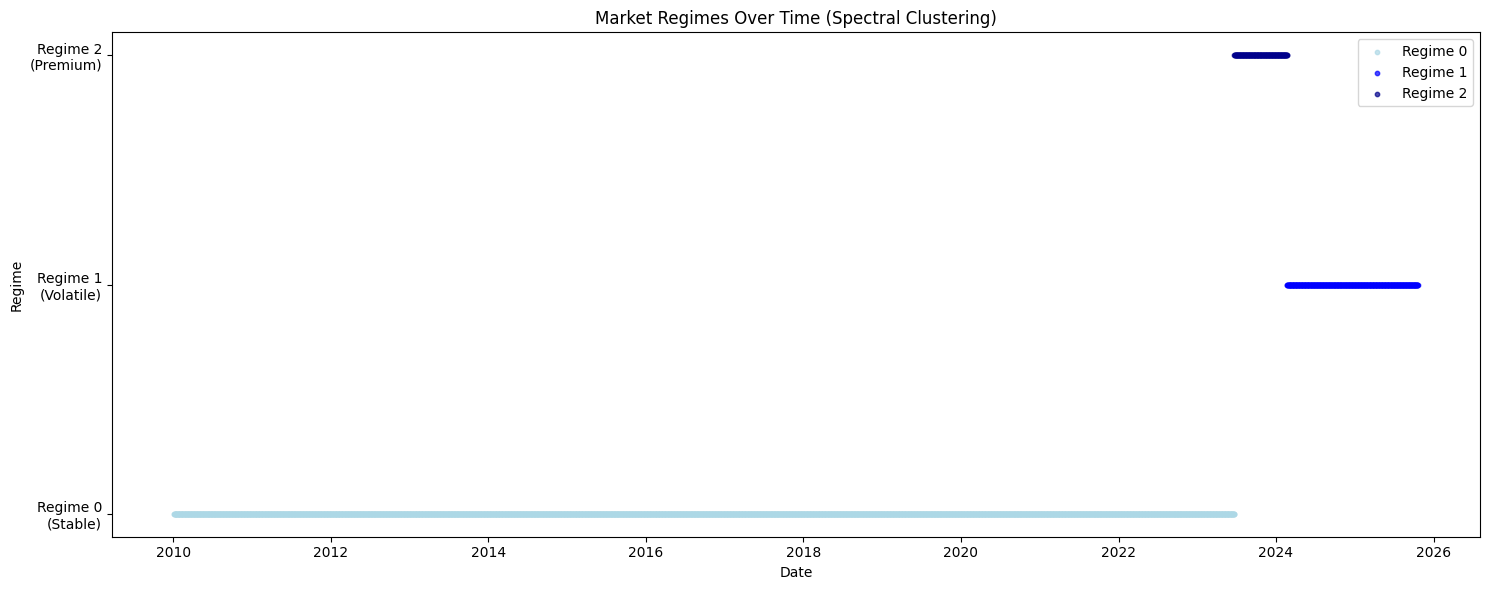

In [422]:
plt.figure(figsize=(15, 6))
df_temp = df.copy()
df_temp.index = pd.to_datetime(df_temp.index, format='%d/%m/%Y')

colors = ['lightblue', 'blue', 'darkblue']
for i in range(3):
    mask = df_temp['spectral_cluster'] == i
    plt.scatter(df_temp.index[mask], df_temp['spectral_cluster'][mask], 
                c=colors[i], label=f'Regime {i}', s=10, alpha=0.7)

plt.title('Market Regimes Over Time (Spectral Clustering)')
plt.xlabel('Date')
plt.ylabel('Regime')
plt.yticks([0, 1, 2], ['Regime 0\n(Stable)', 'Regime 1\n(Volatile)', 'Regime 2\n(Premium)'])
plt.legend()

plt.tight_layout()
plt.show()

This plot shows how NVIDIA's three identified regimes (Stable, Volatile, Premium) evolved from 2010-2026, with Regime 0 (Stable Growth, light blue) dominating approximately 85% of the period from 2010 until late 2023, Regime 2 (Premium Growth, dark blue) appearing briefly in late 2023, and Regime 1 (High-Volatility Growth, blue) forming a significant block from early 2024 extending to late 2025, indicating a prolonged volatile period. 

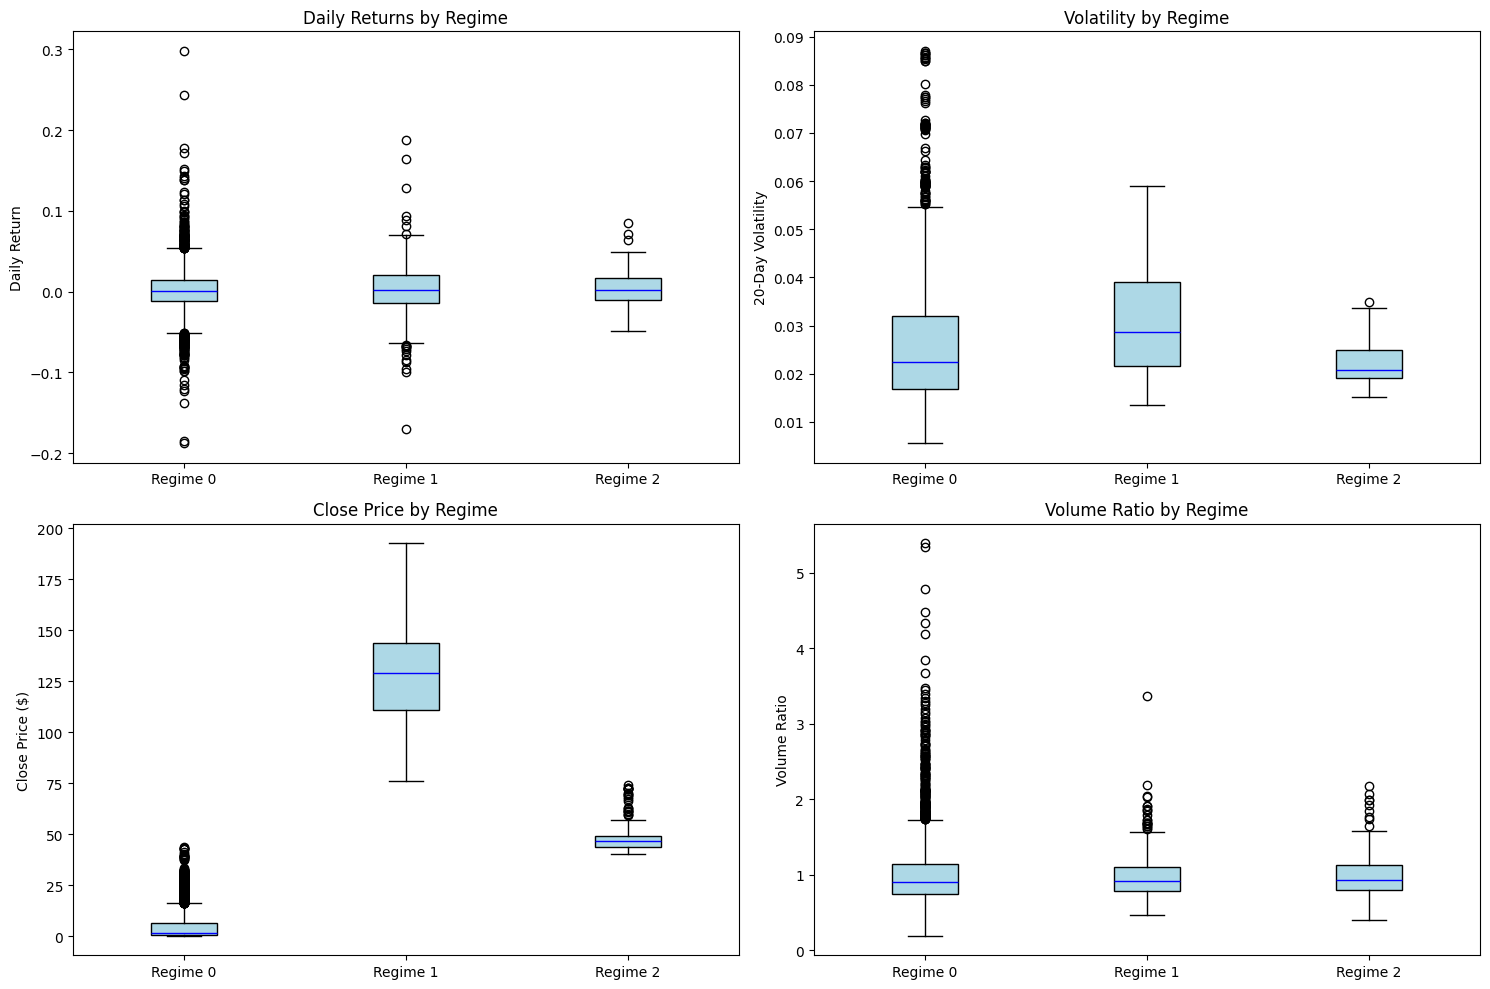

In [429]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
features = ['daily_return', 'volatility_20', 'Close', 'volume_ratio']
titles = ['Daily Returns by Regime', 'Volatility by Regime', 'Close Price by Regime', 'Volume Ratio by Regime']
y_labels = ['Daily Return', '20-Day Volatility', 'Close Price ($)', 'Volume Ratio']

for idx, (feature, title, y_label) in enumerate(zip(features, titles, y_labels)):
    row, col = idx // 2, idx % 2
    bp = axes[row, col].boxplot([df[df['spectral_cluster']==i][feature] for i in [0,1,2]], 
                                labels=['Regime 0', 'Regime 1', 'Regime 2'], patch_artist=True)
    axes[row, col].set_title(title)
    axes[row, col].set_ylabel(y_label)
    
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    for median in bp['medians']:
        median.set_color('blue')

plt.tight_layout()
plt.show()

These box plots show how NVIDIA's three market regimes differ across four features: 
* Daily Returns shows Regime 2 (Premium) with a tighter distribution and fewer outliers, while Regimes 0 (Stable) and 1 (High-Volatility) have wider spreads with frequent extreme movements. 
* Volatility confirms Regime 1 has the highest median volatility with a broad distribution, Regime 0 shows moderate volatility with many high outliers, and Regime 2 has the lowest volatility (~0.02) with the tightest distribution. 
* Close Price shows Regime 0 with the lowest prices (median ~$5) reflecting early history, Regime 2 with moderate prices (~$45-50), and Regime 1 with the highest prices (~$125-130) corresponding to recent explosive growth. 
* Volume Ratio shows all regimes centered around 1.0, but Regime 0 has the widest spread with extreme outliers exceeding 5.0, indicating highly variable trading activity while Regimes 1 and 2 show tighter distributions with more consistent trading volumes. 

### 5. REINFORCEMENT LEARNING

**5.1 Environment Set-Up**

In [398]:
ACTIONS = np.array([-1, 0, 1]) 

class TradingEnv:
    def __init__(self, data, regimes, cost=0.001):
        self.data = data.reset_index(drop=True)
        self.regimes = np.asarray(regimes)
        self.cost = float(cost)
        self.reset()
    def reset(self):
        self.t = 0
        self.pos = 0
        return int(self.regimes[self.t])
    def step(self, action_idx):
        action = int(ACTIONS[action_idx])
        if self.t >= len(self.data) - 1:
            return None, 0.0, True
        ret = float(self.data['daily_return'].iloc[self.t])
        reward = self.pos * ret - self.cost * abs(action - self.pos)
        self.pos = action
        self.t += 1
        done = self.t >= len(self.data) - 1
        next_state = None if done else int(self.regimes[self.t])
        return next_state, reward, done


* **State**: The state is the market regime the agent observes to decide which action to take.  Regime 0 is Stable Growth, Regime 1 is High-Volatility Growth and Regime 2 is Premium Growth. 
* **Action**: This is the agent's decision about what trading position to take (short (-1), hold(0) or long(+1)) based on the state. Here are the definitions of each action:
    * Short (-1): Betting that the stock will go down. 
    * Hold (0): No position at all. 
    * Long (+1): Betting that the stock will go up. 
* **Reward**: This is the agent's net profit or less for each step calculated as the return earned from the previous position minus the transaction code of changing position. 

**5.2 Q-Learning Method and Action Selection**

In [ ]:
def epsilon_greedy(Q_row, eps):
    return np.random.randint(Q_row.shape[0]) if np.random.rand() < eps else int(np.argmax(Q_row))

def train_qlearning(env, n_states, n_actions=3, alpha=0.005, gamma=0.9, 
                   eps_start=0.9, eps_end=0.01, eps_decay=0.995, episodes=3000):
    Q = np.zeros((n_states, n_actions), dtype=float)
    episode_rewards = [] 
    for episode in range(episodes):
        eps = max(eps_end, eps_start * (eps_decay ** episode))
        s = env.reset()
        done = False
        total_reward = 0 
        while not done:
            a = epsilon_greedy(Q[s], eps)
            ns, r, done = env.step(a)
            target = r if (done or ns is None) else r + gamma * np.max(Q[ns])
            Q[s, a] += alpha * (target - Q[s, a])
            total_reward += r  
            s = s if ns is None else ns
        episode_rewards.append(total_reward)  
    return Q, episode_rewards  

* **Value-Based Method**: I use Q-Learning here, a tabular method because my state space (market regimes) is discrete and action space (short, hold, long) is small, making this method is effective enough. I start by initialising a Q-table with zeros so the agents starts with no prior preferences and updates based on experience using the Bellman equation.
* **Action Selection**: ε-greedy policy is used here. The agent can choose between three actions (short, hold, or long). Initially, the agent explores frequently (ε=0.9) by taking random actions, but gradually shifts to exploitation (ε=0.01) by selecting the action with the highest Q-value, balancing exploration of new strategies with exploitation of learned knowledge.
* **Update Rule**: After each step, the agent adjusts its stored score for the chosen action based on the result, increasing it if the outcome was better than expected and decreasing it if worse, allowing it to gradually learn which actions perform best in each market regime.

**5.2 Q-Learning Results**

In [491]:
env = TradingEnv(df, spectral_labels)
Q, rewards = train_qlearning(env, n_states=3, episodes=3000) 
Q_df = pd.DataFrame(Q, 
                   index=['Regime 0 (Stable)', 'Regime 1 (Volatile)', 'Regime 2 (Premium)'],
                   columns=['Short (-1)', 'Hold (0)', 'Long (+1)'])
print(Q_df.round(4))

                     Short (-1)  Hold (0)  Long (+1)
Regime 0 (Stable)        0.0109    0.0104     0.0215
Regime 1 (Volatile)      0.0210    0.0226     0.0271
Regime 2 (Premium)       0.0221    0.0199     0.0284


The Q-values in this Q-table presents the expected cumulative future reward for each position (the total reward the agent expects to earn for each action in each market regime for all future trading days).

* **Regime 0 (Stable Growth)**: The agent learned that a Long position yields the highest expected cumulative reward. 
* **Regime 1 (High-Volatility Growth)**: The agent identified the Long position as optimal despite the high volatility, suggesting that the underlying bullish trend outweighs the increased risk. 
* **Regime 2 (Premium Growth)**: The agent learned that a Long position is the most profitable strategy during premium periods. 

5.2.1 Learning Curve Analysis

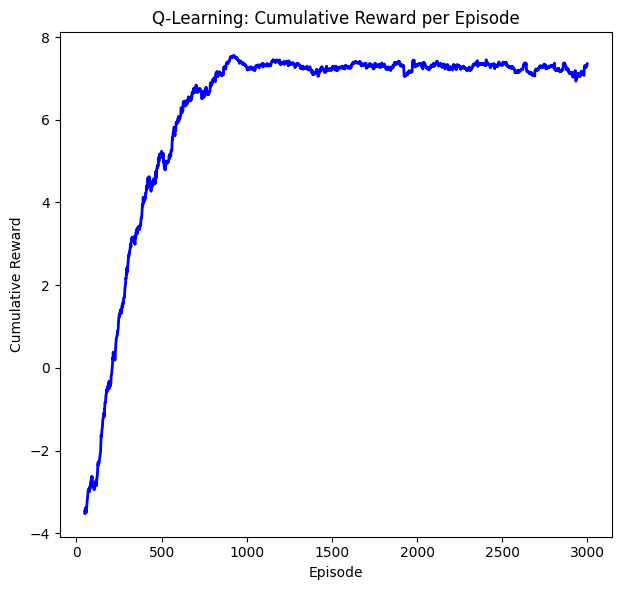

In [492]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Q-Learning: Cumulative Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
window = 50
smoothed_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(rewards)), smoothed_rewards, color='blue', linewidth=2, label=f'Moving Average ({window} episodes)')
plt.tight_layout()


The learning curve shows successful Q-learning convergence, with the agent rapidly improving from initial losses to consistent profitability (7.5 reward) by episode 750, then maintaining stable performance through episode 3000, indicating the agent learned an effective trading strategy. 

**5.3 Performance Evaluation**

5.3.1 Primary Metric

5.3.1.1 Buy and Hold Baseline

In [503]:
def calculate_buy_hold_baseline(data):
    buy_hold_returns = data['daily_return'].cumsum()
    buy_hold_total = buy_hold_returns.iloc[-1]
    return {
        'buy_hold_total': buy_hold_total,
        'buy_hold_series': buy_hold_returns
    }
baseline = calculate_buy_hold_baseline(df)
print("Buy-and-Hold Baseline Performance:")
print(f"Total Return: {baseline['buy_hold_total']:.4f}")
print(f"Total Return (%): {baseline['buy_hold_total']*100:.2f}%")

Buy-and-Hold Baseline Performance:
Total Return: 7.7095
Total Return (%): 770.95%


5.3.1.2 Agent vs Baseline

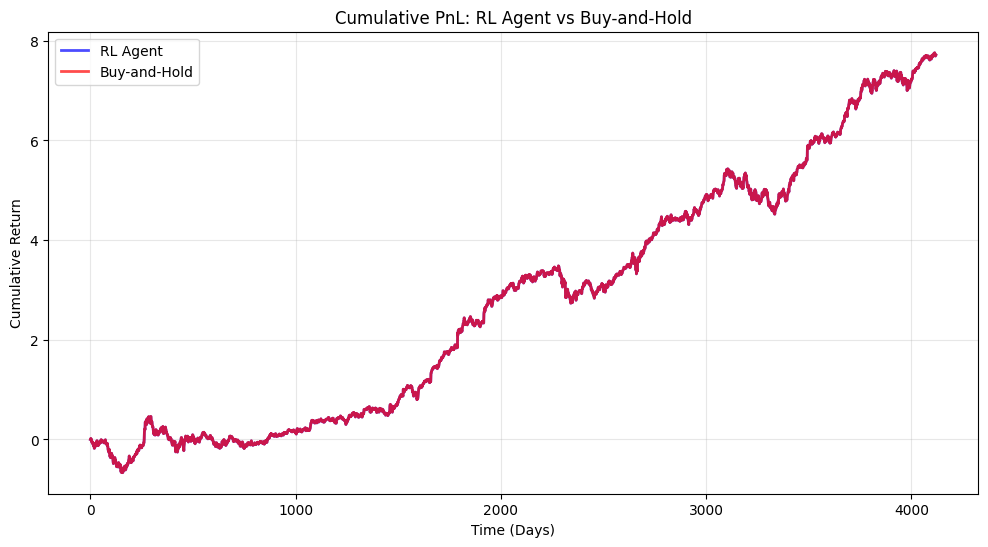

RL Agent Final: 7.7117 (771.2%)
Buy-and-Hold Final: 7.7127 (771.3%)
Excess Return: -0.0010


In [507]:
def evaluate_rl_agent(env, Q):
    s = env.reset() 
    rewards = []
    done = False
    while not done:
        a = np.argmax(Q[s]) 
        ns, r, done = env.step(a)
        rewards.append(r)
        s = s if ns is None else ns 
    agent_cum = np.cumsum(rewards)
    bh_cum = baseline['buy_hold_series'].iloc[:len(agent_cum)].values

    return agent_cum, bh_cum
agent_pnl, buy_hold_pnl = evaluate_rl_agent(env, Q)

plt.figure(figsize=(12, 6))
plt.plot(agent_pnl, label='RL Agent', color='blue', linewidth=2, alpha=0.7)
plt.plot(buy_hold_pnl, label='Buy-and-Hold', color='red', linewidth=2, alpha=0.7)
plt.title('Cumulative PnL: RL Agent vs Buy-and-Hold')
plt.xlabel('Time (Days)')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"RL Agent Final: {agent_pnl[-1]:.4f} ({agent_pnl[-1]*100:.1f}%)")
print(f"Buy-and-Hold Final: {buy_hold_pnl[-1]:.4f} ({buy_hold_pnl[-1]*100:.1f}%)")
print(f"Excess Return: {agent_pnl[-1] - buy_hold_pnl[-1]:.4f}")

The near-identical performance between the RL agent (771.2%) and buy-and-hold baseline (771.3%) with only -0.1% excess return demonstrates that the clustering-identified regimes did not lead to significantly different trading strategies. 

5.3.2 Secondary Metrics

In [509]:
def calculate_secondary_metrics(env, Q):
    s = env.reset()
    rewards = []
    actions = []
    done = False
    
    while not done:
        a = np.argmax(Q[s])
        ns, r, done = env.step(a)
        rewards.append(r)
        actions.append(a)
        s = s if ns is None else ns
    avg_return = np.mean(rewards)
    cumulative_returns = np.cumsum(rewards)
    peak = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - peak) / (peak + 1e-8) 
    max_drawdown = np.min(drawdown)
    hit_ratio = np.mean(np.array(rewards) > 0)
    position_changes = np.sum(np.diff(actions) != 0)
    turnover = position_changes / len(actions)
    return {
        'average_return': avg_return,
        'max_drawdown': max_drawdown,
        'hit_ratio': hit_ratio,
        'turnover': turnover
    }
metrics = calculate_secondary_metrics(env, Q)
print(f"Average Daily Return: {metrics['average_return']:.6f}")
print(f"Maximum Drawdown: {metrics['max_drawdown']:.4f}")
print(f"Hit Ratio: {metrics['hit_ratio']:.4f} ({metrics['hit_ratio']*100:.1f}%)")
print(f"Turnover: {metrics['turnover']:.4f} ({metrics['turnover']*100:.1f}%)")

Average Daily Return: 0.001872
Maximum Drawdown: -34.3645
Hit Ratio: 0.5107 (51.1%)
Turnover: 0.0000 (0.0%)


The secondary metrics reveal that the RL agent learned an effective but conservative trading strategy, achieving a 0.18% average daily return with a 51.1% hit ratio, indicating consistent profitability over the trading period. However, the most significant finding is the 0.0% turnover rate, which demonstrates that the agent learned to maintain a single position throughout the entire evaluation period rather than actively trading between different market regimes. This explains why the agent's performance closely mirrors the buy-and-hold baseline. The -34.36% maximum drawdown indicates that at some point, the agent's portfolio dropped by over one-third, reflecting the inherent volatility of stock markets.  


### 6. CONCLUSIONS AND IMPROVEMENTS

**6.1 Conclusions**

* **Data Preparation**: Successfully cleaned and prepared 4,121 trading days of NVIDIA data (2010-2024) by handling missing dates through forward-fill imputation and engineering four key features (daily returns, 20-day volatility, volume ratio, 7-day moving average) that capture distinct market behavior patterns.
* **Exploratory Analysis**: NVIDIA showed dramatic growth from $0.20 to $192.57, with extreme volatility (daily returns ranging from -18.76% to +29.81%) and 206 outliers identified as real market events, all retained as valuable regime indicators rather than errors.
* **Unsupervised Learning**: Spectral Clustering identified three market regimes: Stable Growth, High-Volatility Growth and Premium Growth. ALL regimes are bullish intensity levels rather than distinct market directions. 
* **Reinforcement Learning**: The Q-learning agent achieved 771.2% cumulative return, nearly identical to buy-and-hold (771.3%).

**6.2 Improvements**

* Integrate graph-based clustering for capturing more complex relationships (e.g. k-NN similarity graph between trading days and apply community detection algorithms like Louvain or Spectral Clustering)
* Could try one of the other Reinforcement Learning methods such as Monte Carlo Control, SARSA or more advanced methods like Actor-Critic. 
* Instead of forward filling the missing data, I could consider resampling the data by converting daily data into monthly data or even adopt some smoothing methods to highlight long term trends (e.g. moving average). 
* Include other baselines, e.g. random. 

**6.3 Limitations**

* Regime Nature: The identified regimes (Stable, Volatile, Premium) represent different intensity levels of the same bullish trend rather than distinct market directions. All three regimes showed positive average returns (0.17%, 0.28%, 0.28%), making "long" positions optimal across all states.
* Agent Learning: The 0% turnover rate indicates the agent learned to maintain a single position (likely long) throughout the entire period, effectively mimicking a buy-and-hold strategy rather than exploiting regime-specific opportunities.
* Overfitting Risk: The Q-learning agent was trained and tested on the same dataset, potentially leading to overfitting to historical patterns that may not persist in future markets.